In [38]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

# MQTT Results Analysis

## Important considerations.

* Must explain $SYS stuff in report
* <span style="color:red">Why is the broker consistently sending more than received? Is this not impossible?</span> Interestingly, if I look on the broker now (no tests running), the sent 1min count under load is 29.57 while the received is only 0.87. I assume this is because it's publishing all the $SYS updates, but not really receiving anything. I would expect received to dominate sent when running actual tests though... 

What I think is happening is publisher publishes to broker with qos 0, but analyser subscribes with qos 1 or 2. But what about the fact pattern is the same for analyserQOS==qos? Potentially my laptop has no trouble publishing, but struggles with receiving? This way lot's of messages are sent when receiving, but not many when publishing. But this doesn't explain the fact that analyserQOS==qos==0, pattern is still there?

* Specify that 'rate' is used to refer to units messages/second
* Discuss interesting delivery patterns I collected in figures throughout the test process 

> **Note:**

> Need to clarify that the broker measurements are from $SYS/#/1min, meaning they are a moving average of last minute of results. 
>
> Also note discrepancy between $SYS and current test. Generally, we get $SYS at the start of the test, then the broker is quickly overwhelmed and we don't get any more $SYS measurements for remainder of tests. This means, if we go into the table the $SYS measurements for a given row are generally a more accurate characterisation of the **previous** row.

## Read in the Data

Have to do some cleaning as not all dtypes are numeric. Also, I unfortunately did not increment the test_time properly :( - it only increments every new analyserQos meaning there are only 3 unique values for test_time. This isn't a massive deal though - wasn't very important data anyway.

In [39]:
df = pd.read_csv("/Users/timothyalder/Documents/ANU/ENGN3539/Assignment-Three/test-1/summary.csv")
# Function to clean and convert columns to float where possible
def clean_and_convert(df):
    for col in df.columns:
        if not pd.api.types.is_numeric_dtype(df[col]): 
            # Remove commas
            df[col] = df[col].str.replace(',', '')
            # Convert to float
            df[col] = df[col].astype(float)
    return df

# Apply the function to the DataFrame
df = clean_and_convert(df)
t = np.asarray(df['test_time'])
t1,t2,t3 = np.unique(t)
df.head()

,test_time,qos,analyserQos,instancecount,delay,messages_received,received_rate,loss_rate,out_of_order_rate,median_inter_message_gap,mean_inter_message_gap,variance_inter_message_gap,$SYS/broker/clients/connected,$SYS/broker/load/publish/dropped/1min,$SYS/broker/load/messages/sent/1min,$SYS/broker/load/messages/received/1min,$SYS/broker/messages/inflight
0,1.716120e+09,0,0,1,4,7917.0,131.95,0.38,0,0.12,7.57,0.00,7,0.06,9564.26,4791.87,NaN
1,1.716120e+09,0,0,2,4,4296.0,71.60,57.80,0,10.72,27.52,0.00,7,0.06,7094.97,3593.38,NaN
2,1.716120e+09,0,0,3,4,2998.0,49.97,74.72,0,23.02,61.92,0.01,7,0.06,10432.46,5264.13,NaN
3,1.716120e+09,0,0,4,4,2635.0,43.92,79.83,0,30.54,81.04,0.02,7,0.06,11915.47,6006.62,NaN
4,1.716120e+09,0,0,5,4,1666.0,27.77,87.55,0,64.03,179.17,0.07,6,210.92,12046.33,6440.75,NaN


Construct filtered df which only contains rows where qos==analyserQos

In [40]:
filtered_df = df[df['qos']==df['analyserQos']]
filtered_df.head()

,test_time,qos,analyserQos,instancecount,delay,messages_received,received_rate,loss_rate,out_of_order_rate,median_inter_message_gap,mean_inter_message_gap,variance_inter_message_gap,$SYS/broker/clients/connected,$SYS/broker/load/publish/dropped/1min,$SYS/broker/load/messages/sent/1min,$SYS/broker/load/messages/received/1min,$SYS/broker/messages/inflight
0,1.716120e+09,0,0,1,4,7917.0,131.95,0.38,0,0.12,7.57,0.00,7,0.06,9564.26,4791.87,NaN
1,1.716120e+09,0,0,2,4,4296.0,71.60,57.80,0,10.72,27.52,0.00,7,0.06,7094.97,3593.38,NaN
2,1.716120e+09,0,0,3,4,2998.0,49.97,74.72,0,23.02,61.92,0.01,7,0.06,10432.46,5264.13,NaN
3,1.716120e+09,0,0,4,4,2635.0,43.92,79.83,0,30.54,81.04,0.02,7,0.06,11915.47,6006.62,NaN
4,1.716120e+09,0,0,5,4,1666.0,27.77,87.55,0,64.03,179.17,0.07,6,210.92,12046.33,6440.75,NaN


## Median intermessage gap versus Test Time

See if the broker managed to recover between tests

Notably, delay was 4->0, so median intermessage gap may just be correlated to delay 0 tests. If this is the case, we should see a step function where the step intervals are at each switch to a different delay.

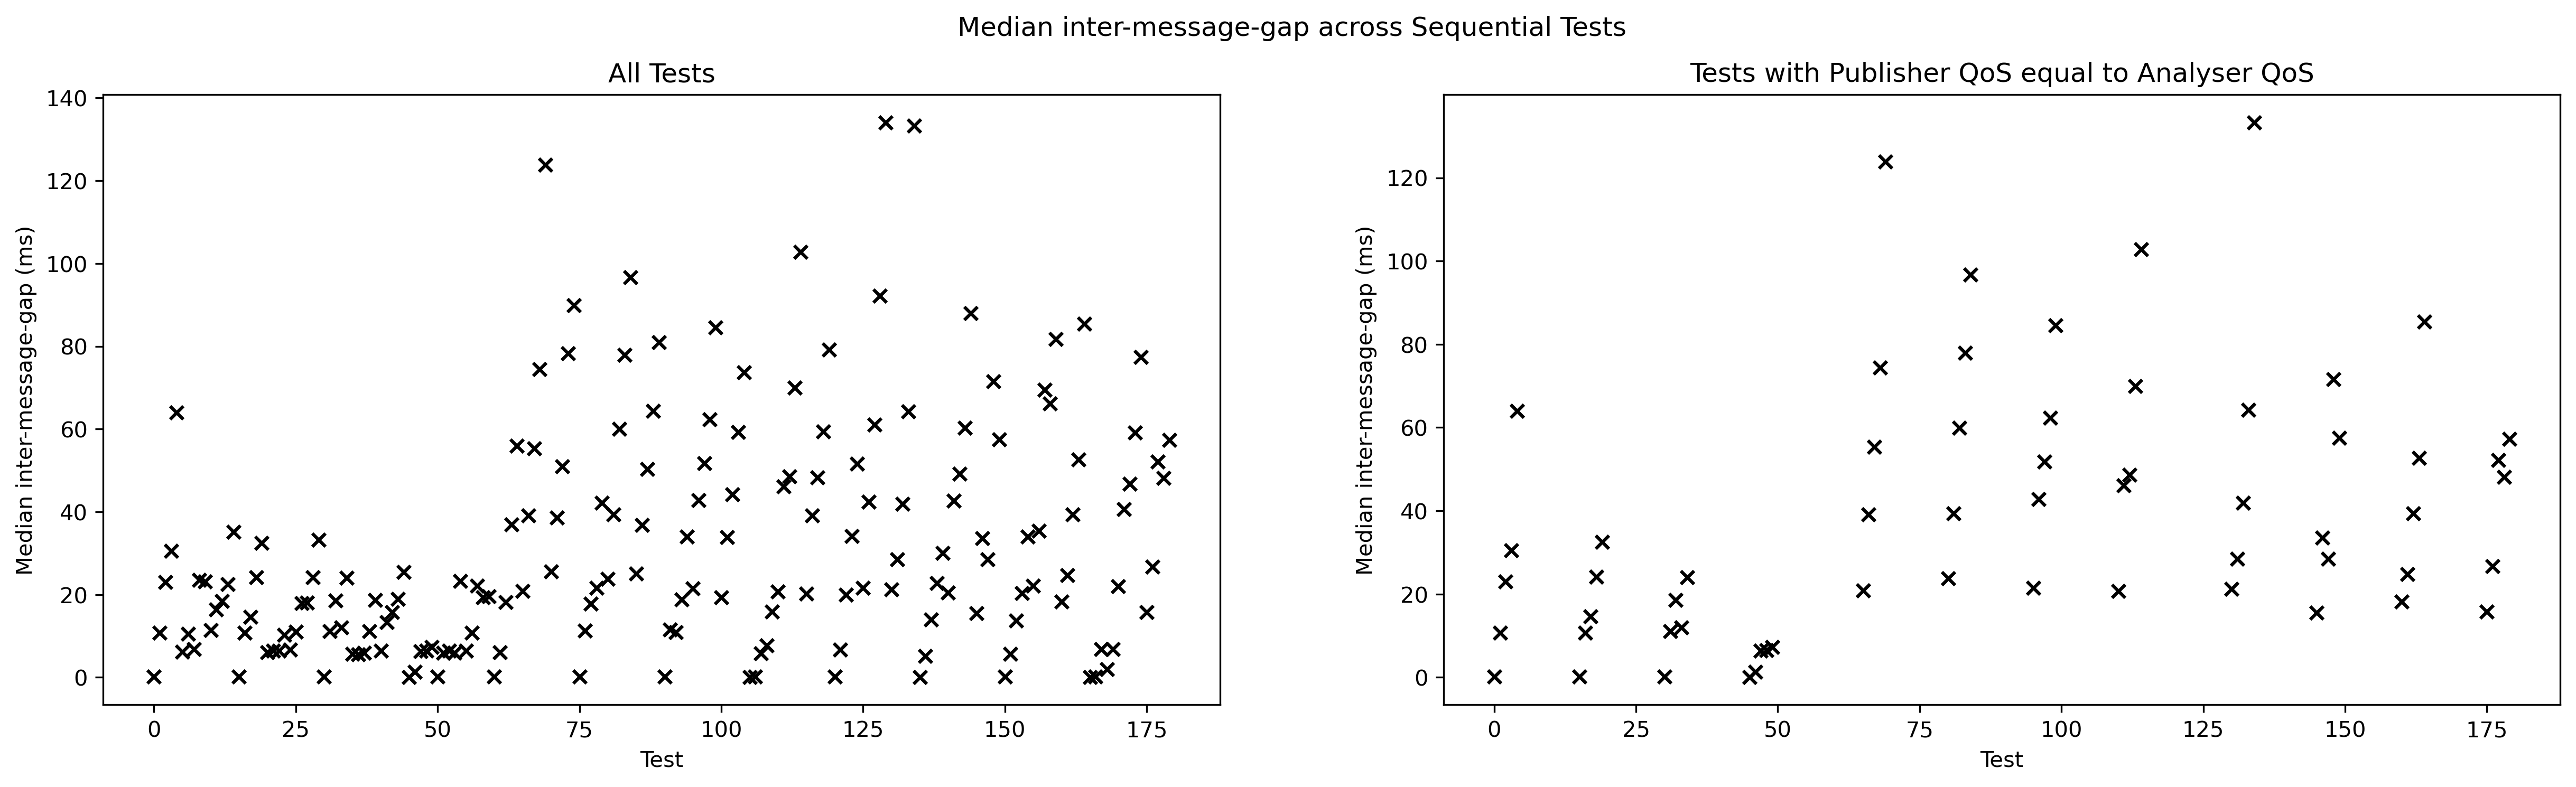

In [41]:
fig, axs = plt.subplots(1,2,figsize=(20,5),dpi=300)
dfs = [df,filtered_df]
labels = ['All Tests','Tests with Publisher QoS equal to Analyser QoS']
for idx,ax in enumerate(axs):
    ax.scatter(dfs[idx].index,dfs[idx]['median_inter_message_gap'],color='black',marker='x')
    ax.set_xlabel('Test')
    ax.set_ylabel('Median inter-message-gap (ms)')
    ax.set_title(labels[idx])
plt.suptitle('Median inter-message-gap across Sequential Tests')
plt.show()

We do see a step occur at test 60, which marks analyser QoS moving from 0->1. This suggests that Analyser QoS is correlated to median inter-message-gap.

## Broker Load versus Test Time

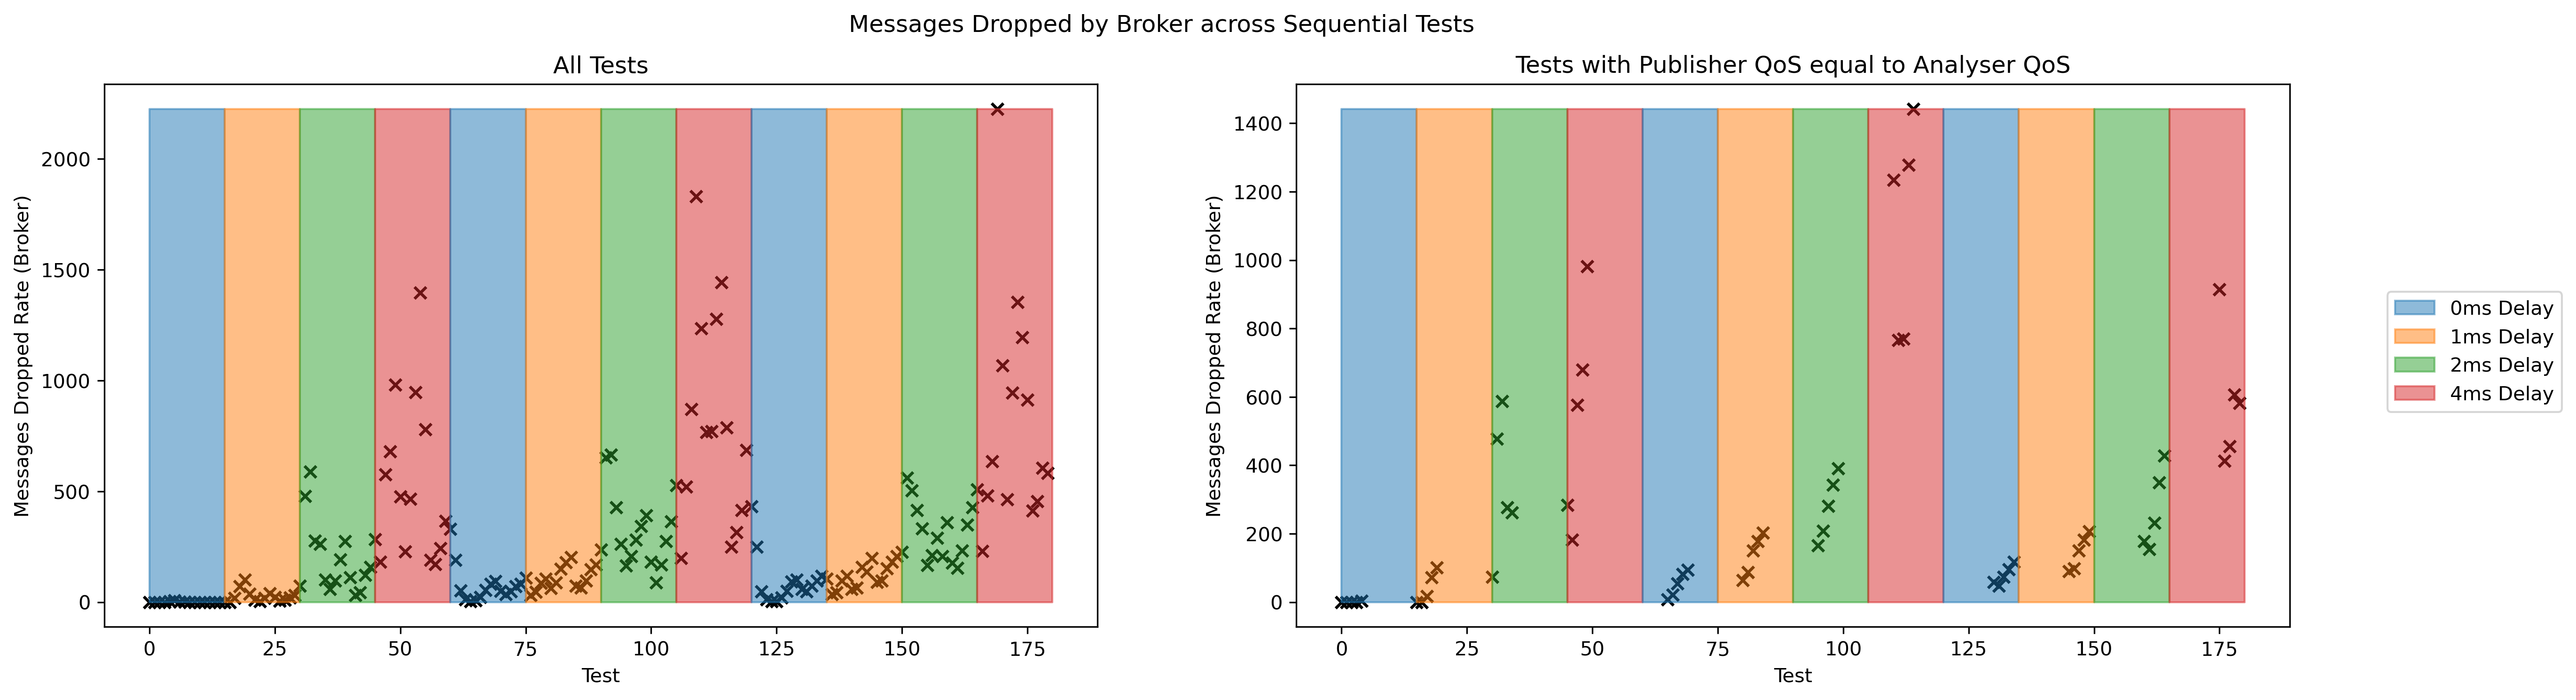

In [42]:
fig, axs = plt.subplots(1,2,figsize=(20,5),dpi=300)
dfs = [df,filtered_df]
labels = ['All Tests','Tests with Publisher QoS equal to Analyser QoS']
vlines = np.arange(0,181,15).tolist()
line_labels = ['0ms Delay', '1ms Delay', '2ms Delay', '4ms Delay']
colors = ['C0','C1','C2','C3']
for idx,ax in enumerate(axs):
    ax.scatter(dfs[idx].index,np.array(dfs[idx]['$SYS/broker/load/publish/dropped/1min'])/60,color='black',marker='x')
    for line_idx,x in enumerate(vlines[:-1]):
        ax.fill_between([x,vlines[line_idx+1]],0,(np.array(dfs[idx]['$SYS/broker/load/publish/dropped/1min'])/60).max(),color=colors[line_idx%4],alpha=0.5,label=line_labels[line_idx%4])
    ax.set_xlabel('Test')
    ax.set_ylabel('Messages Dropped Rate (Broker)')
    ax.set_title(labels[idx])

handles, leg_labels = axs[0].get_legend_handles_labels()
unique_handles_labels = dict(zip(leg_labels[:4], handles[:4]))  # Keep only the first four

fig.legend(unique_handles_labels.values(), unique_handles_labels.keys(), loc='center right', bbox_to_anchor=(1, 0.5))
plt.suptitle('Messages Dropped by Broker across Sequential Tests')
plt.show()

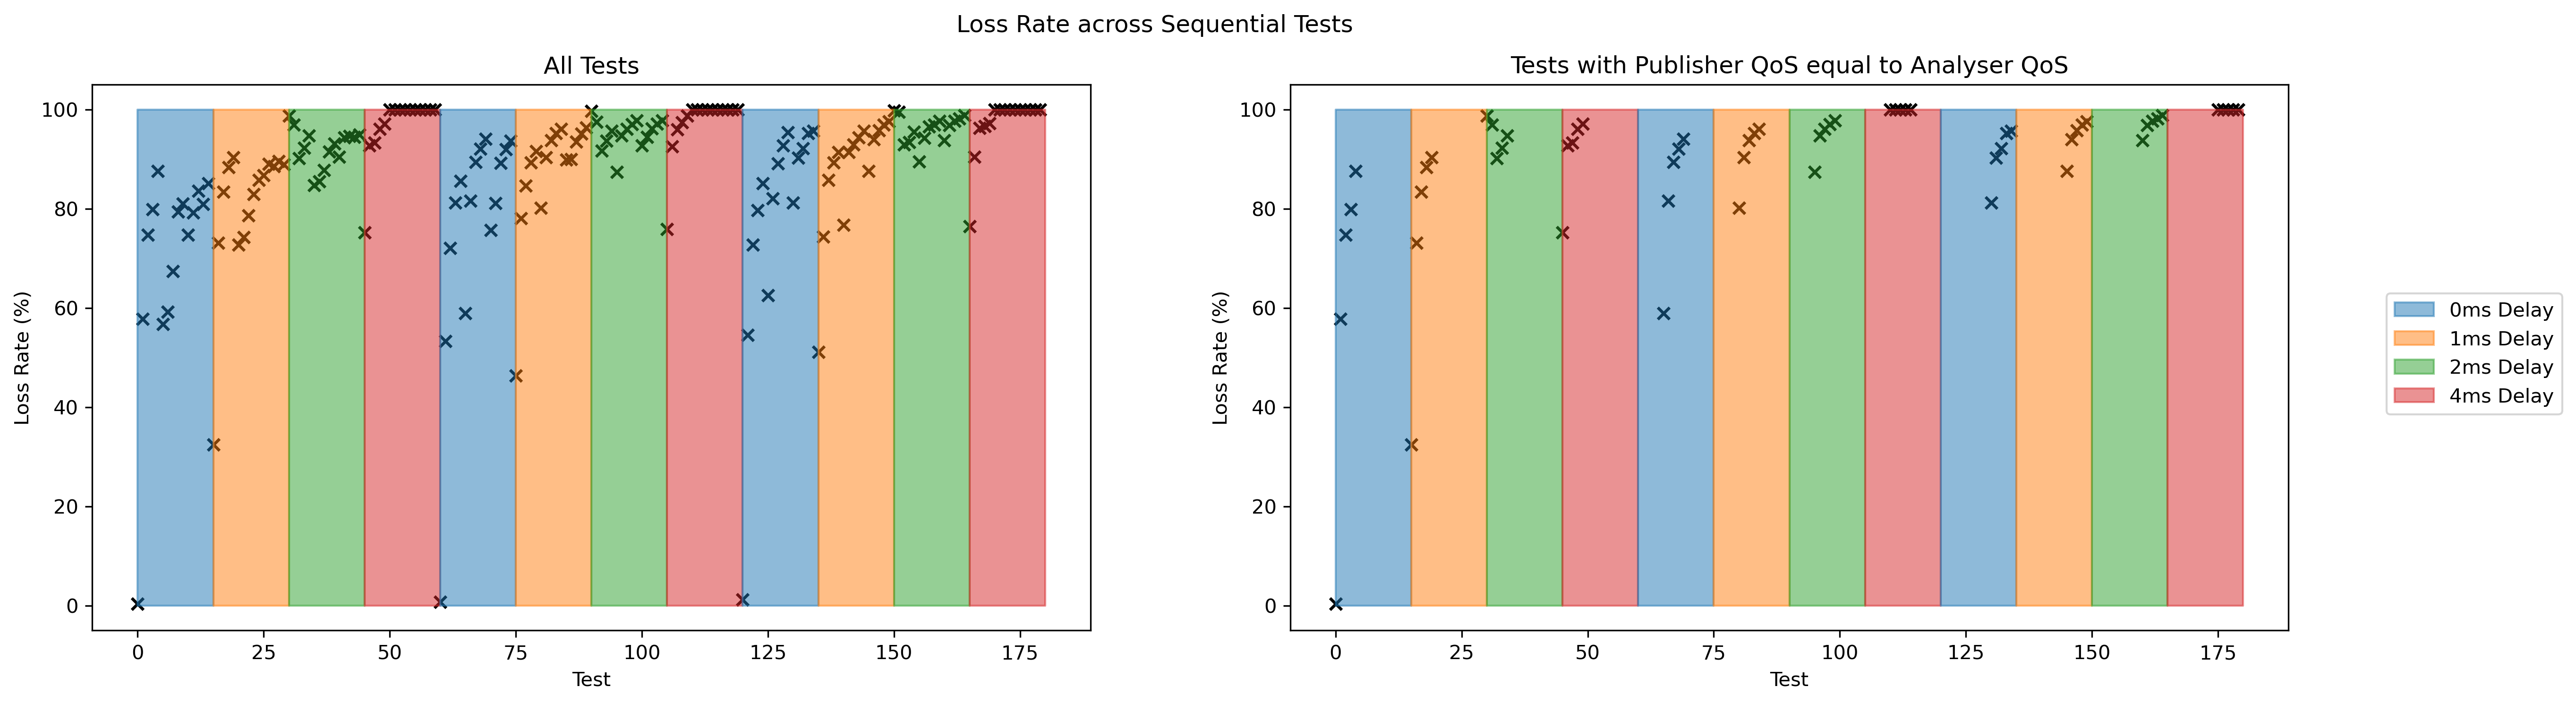

In [43]:
fig, axs = plt.subplots(1,2,figsize=(20,5),dpi=300)
dfs = [df,filtered_df]
labels = ['All Tests','Tests with Publisher QoS equal to Analyser QoS']
vlines = np.arange(0,181,15).tolist()
line_labels = ['0ms Delay', '1ms Delay', '2ms Delay', '4ms Delay']
colors = ['C0','C1','C2','C3']
for idx,ax in enumerate(axs):
    ax.scatter(dfs[idx].index,np.array(dfs[idx]['loss_rate']),color='black',marker='x')
    for line_idx,x in enumerate(vlines[:-1]):
        ax.fill_between([x,vlines[line_idx+1]],0,np.array(dfs[idx]['loss_rate']).max(),color=colors[line_idx%4],alpha=0.5,label=line_labels[line_idx%4])
    ax.set_xlabel('Test')
    ax.set_ylabel('Loss Rate (%)')
    ax.set_title(labels[idx])

handles, leg_labels = axs[0].get_legend_handles_labels()
unique_handles_labels = dict(zip(leg_labels[:4], handles[:4]))  # Keep only the first four

fig.legend(unique_handles_labels.values(), unique_handles_labels.keys(), loc='center right', bbox_to_anchor=(1, 0.5))
plt.suptitle('Loss Rate across Sequential Tests')
plt.show()

## Median inter-message-gap versus QoS

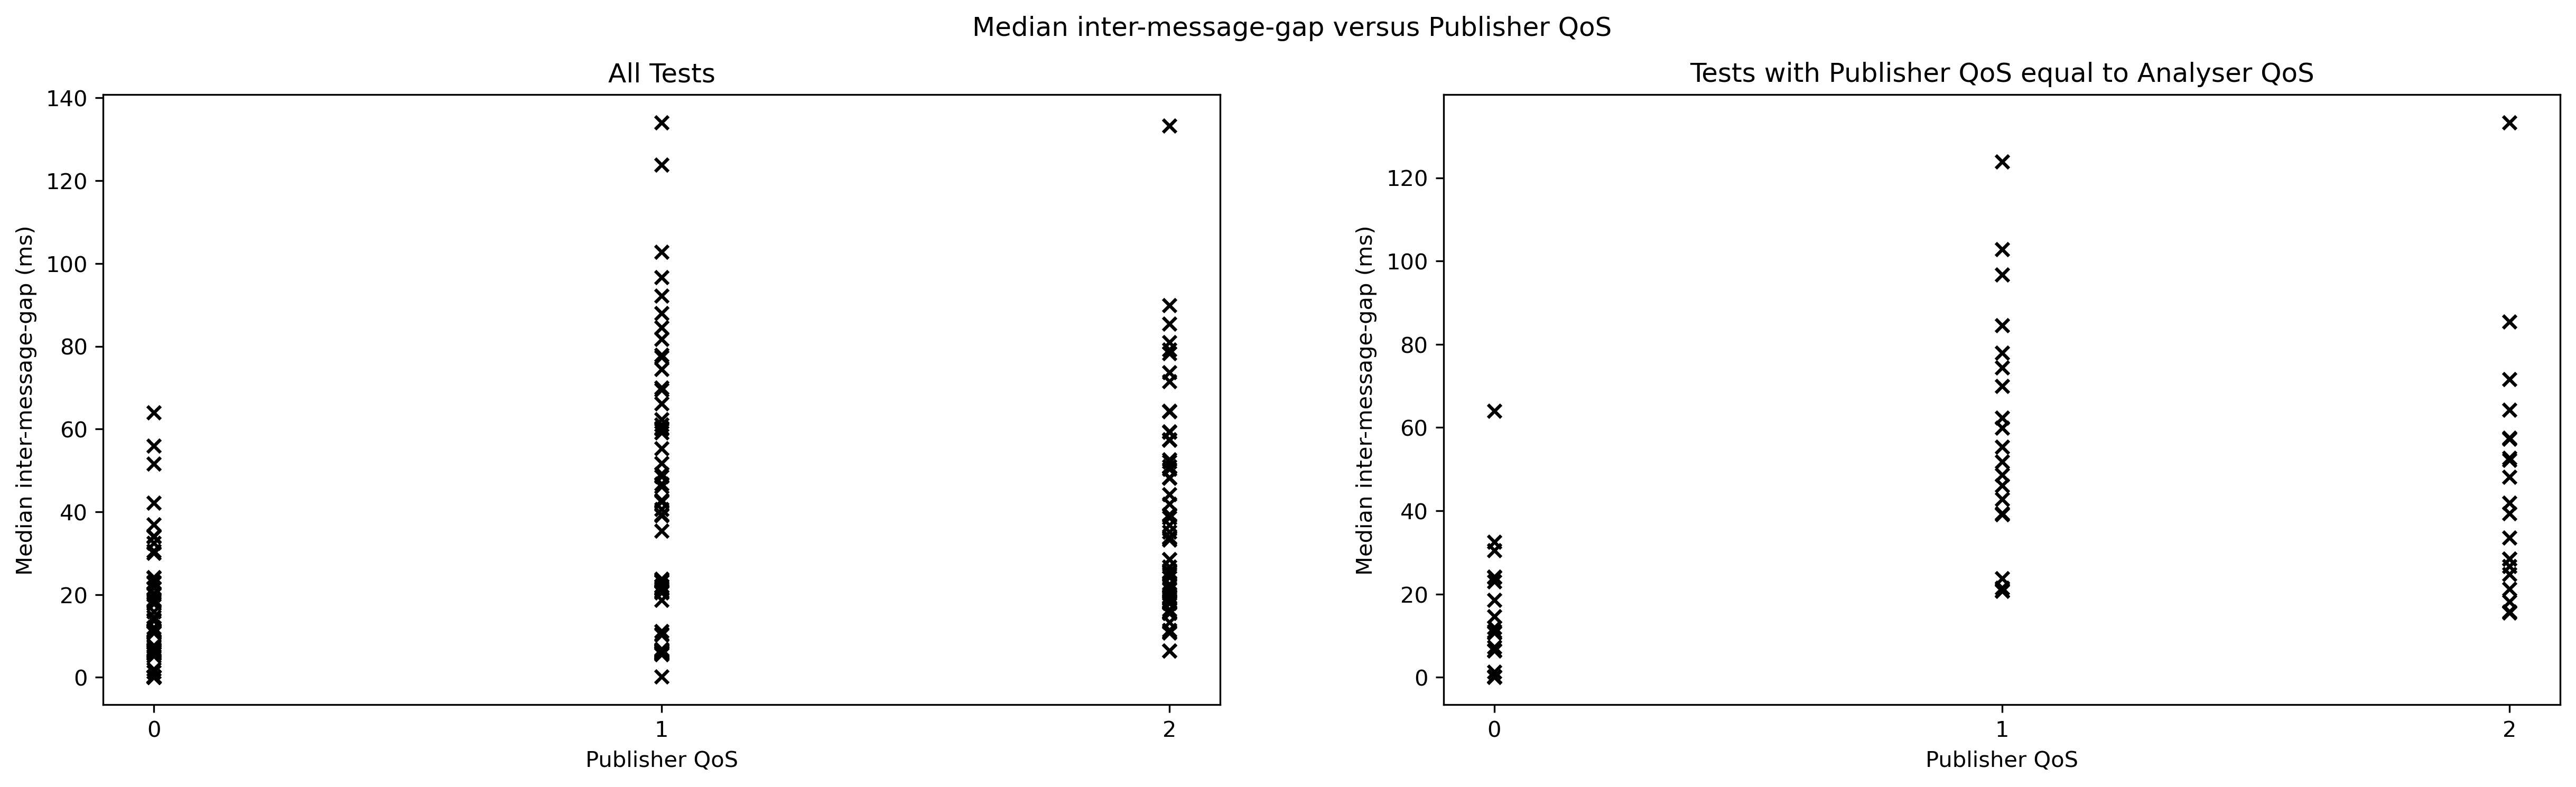

In [44]:
fig, axs = plt.subplots(1,2,figsize=(20,5),dpi=300)
dfs = [df,filtered_df]
for idx,ax in enumerate(axs):
    ax.scatter(dfs[idx]['qos'],dfs[idx]['median_inter_message_gap'],color='black',marker='x')
    ax.set_xlabel('Publisher QoS')
    ax.set_ylabel('Median inter-message-gap (ms)')
    ax.set_xticks([0,1,2])
    ax.set_title(labels[idx])
plt.suptitle('Median inter-message-gap versus Publisher QoS')
plt.show()

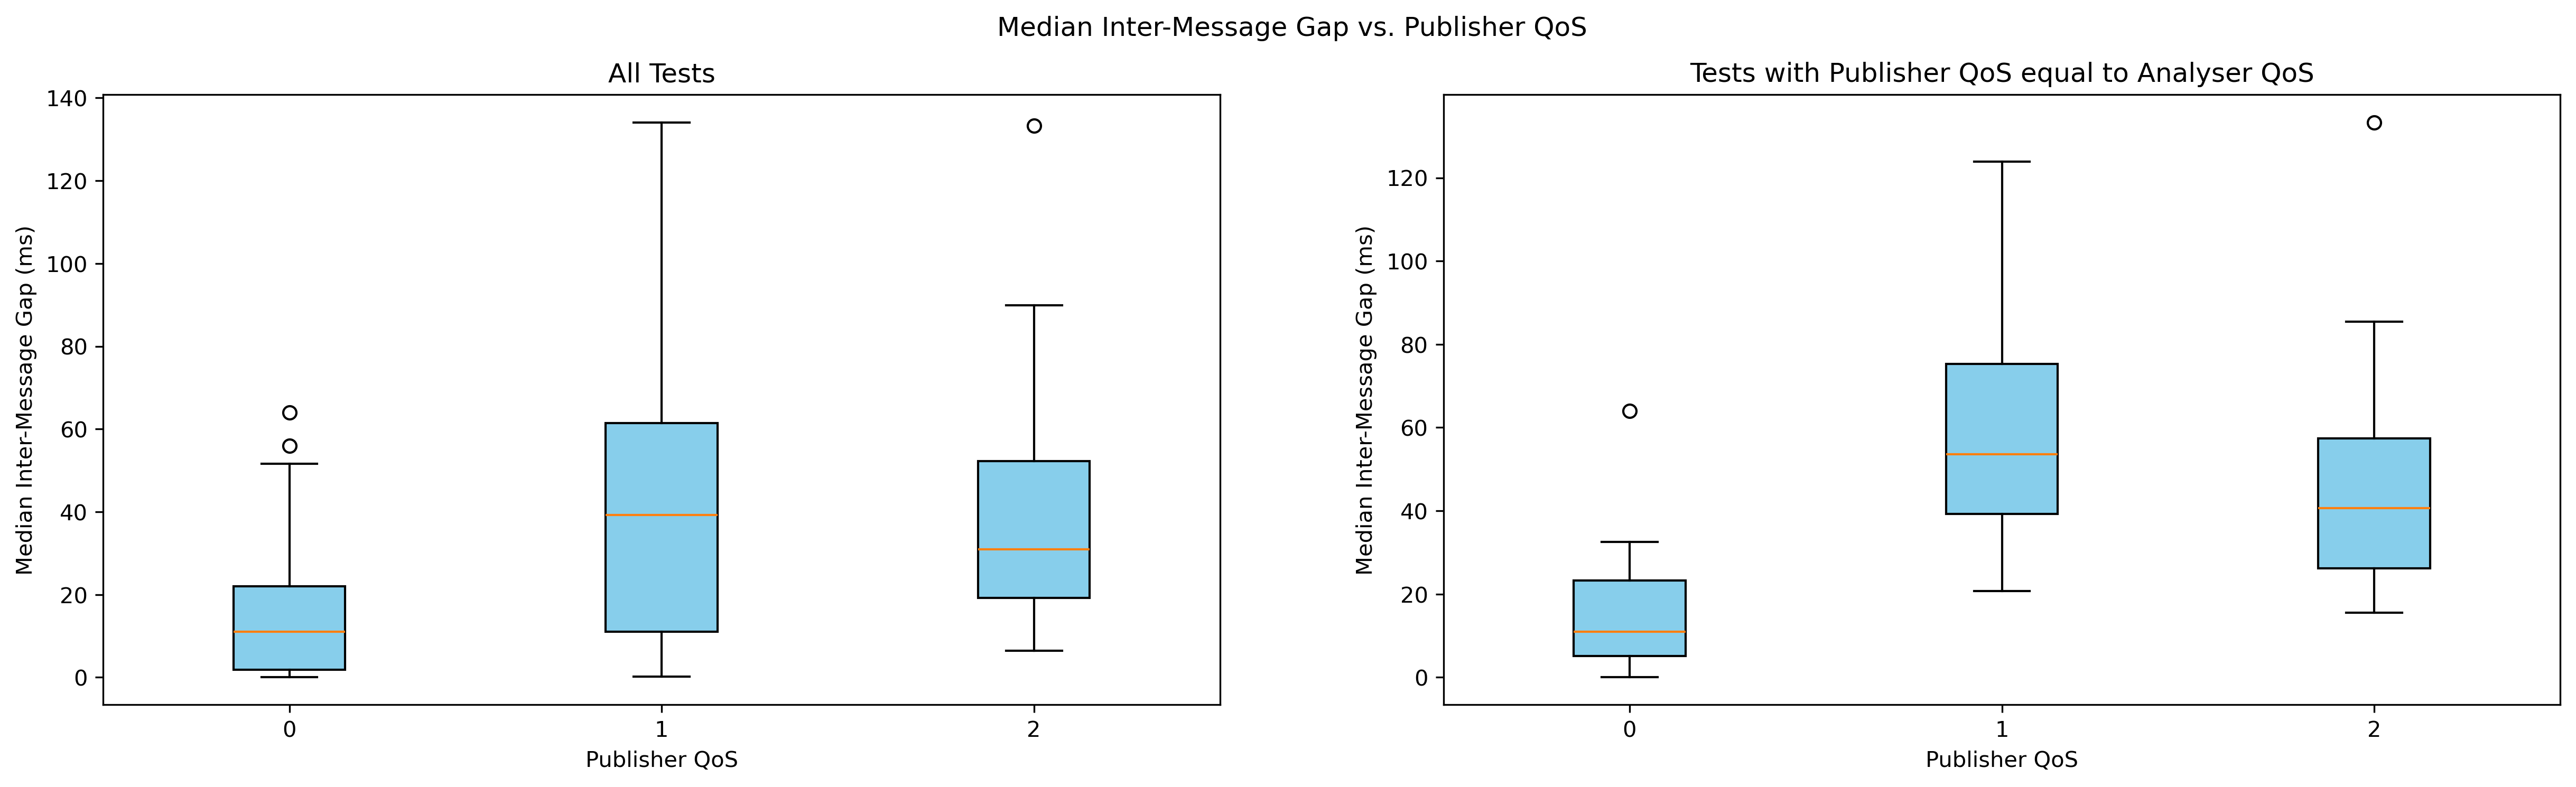

In [45]:
fig, axs = plt.subplots(1, 2, figsize=(20, 5), dpi=300)
dfs = [df, filtered_df]

for idx, ax in enumerate(axs):
    # Group data by 'qos' and collect the 'median_inter_message_gap' values
    grouped_data = [dfs[idx].loc[dfs[idx]['qos'] == qos, 'median_inter_message_gap'] for qos in [0, 1, 2]]
    
    # Create a box plot
    ax.boxplot(grouped_data, labels=[0, 1, 2], patch_artist=True, boxprops=dict(facecolor="skyblue"))
    ax.set_xlabel('Publisher QoS')
    ax.set_ylabel('Median Inter-Message Gap (ms)')
    ax.set_title(labels[idx])
    ax.set_xticks([1, 2, 3])  # Set the x-ticks to correspond to the QoS labels

plt.suptitle('Median Inter-Message Gap vs. Publisher QoS')
plt.show()


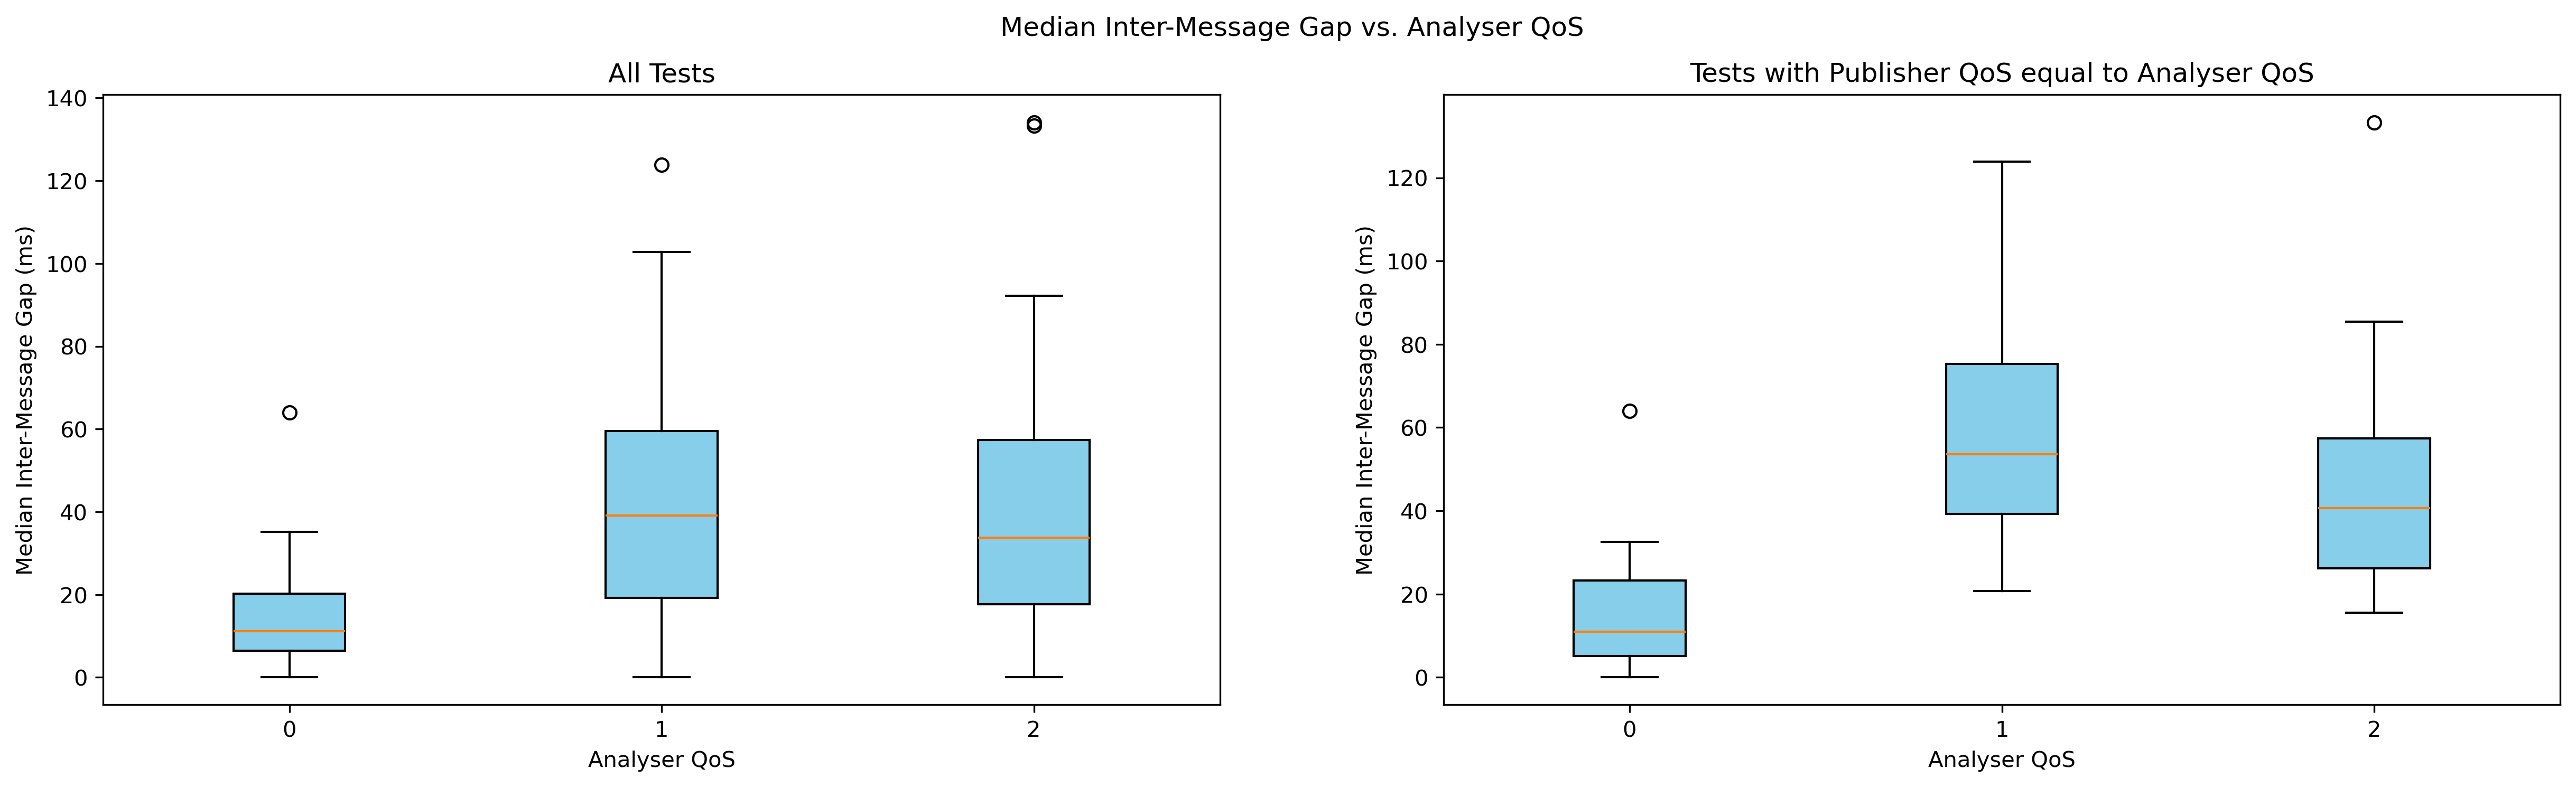

In [46]:
fig, axs = plt.subplots(1, 2, figsize=(20, 5), dpi=300)
dfs = [df, filtered_df]

for idx, ax in enumerate(axs):
    # Group data by 'qos' and collect the 'median_inter_message_gap' values
    grouped_data = [dfs[idx].loc[dfs[idx]['analyserQos'] == qos, 'median_inter_message_gap'] for qos in [0, 1, 2]]
    
    # Create a box plot
    ax.boxplot(grouped_data, labels=[0, 1, 2], patch_artist=True, boxprops=dict(facecolor="skyblue"))
    ax.set_xlabel('Analyser QoS')
    ax.set_ylabel('Median Inter-Message Gap (ms)')
    ax.set_title(labels[idx])
    ax.set_xticks([1, 2, 3])  # Set the x-ticks to correspond to the QoS labels

plt.suptitle('Median Inter-Message Gap vs. Analyser QoS')
plt.show()


## Median inter-message-gap versus Instancecount

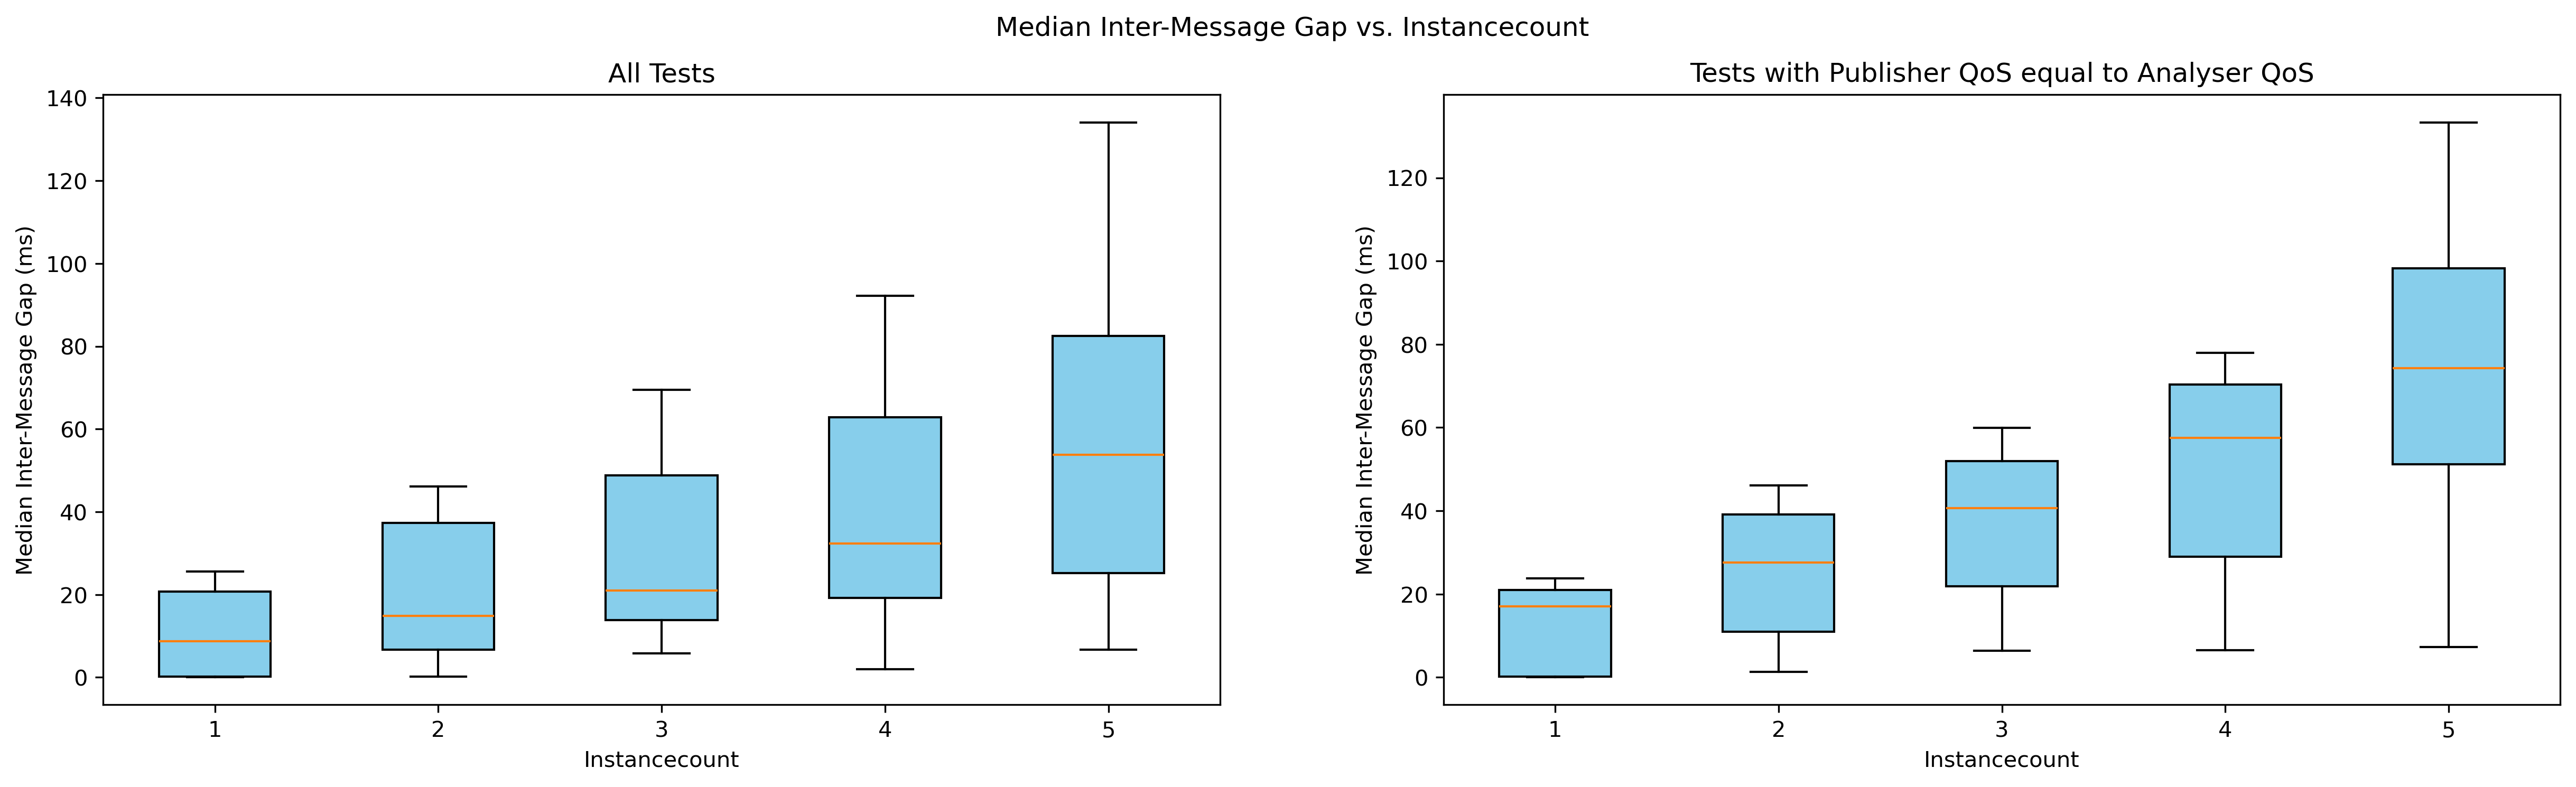

In [47]:
fig, axs = plt.subplots(1, 2, figsize=(20, 5), dpi=300)
dfs = [df, filtered_df]

for idx, ax in enumerate(axs):
    # Group data by 'qos' and collect the 'median_inter_message_gap' values
    grouped_data = [dfs[idx].loc[dfs[idx]['instancecount'] == instancecount, 'median_inter_message_gap'] for instancecount in [1, 2, 3, 4, 5]]
    
    # Create a box plot
    ax.boxplot(grouped_data, labels=[1, 2, 3, 4, 5], patch_artist=True, boxprops=dict(facecolor="skyblue"))
    ax.set_xlabel('Instancecount')
    ax.set_ylabel('Median Inter-Message Gap (ms)')
    ax.set_title(labels[idx])
    ax.set_xticks([1, 2, 3,4,5])  # Set the x-ticks to correspond to the QoS labels

plt.suptitle('Median Inter-Message Gap vs. Instancecount')
plt.show()

# Median inter-message-gap versus Requested Delay

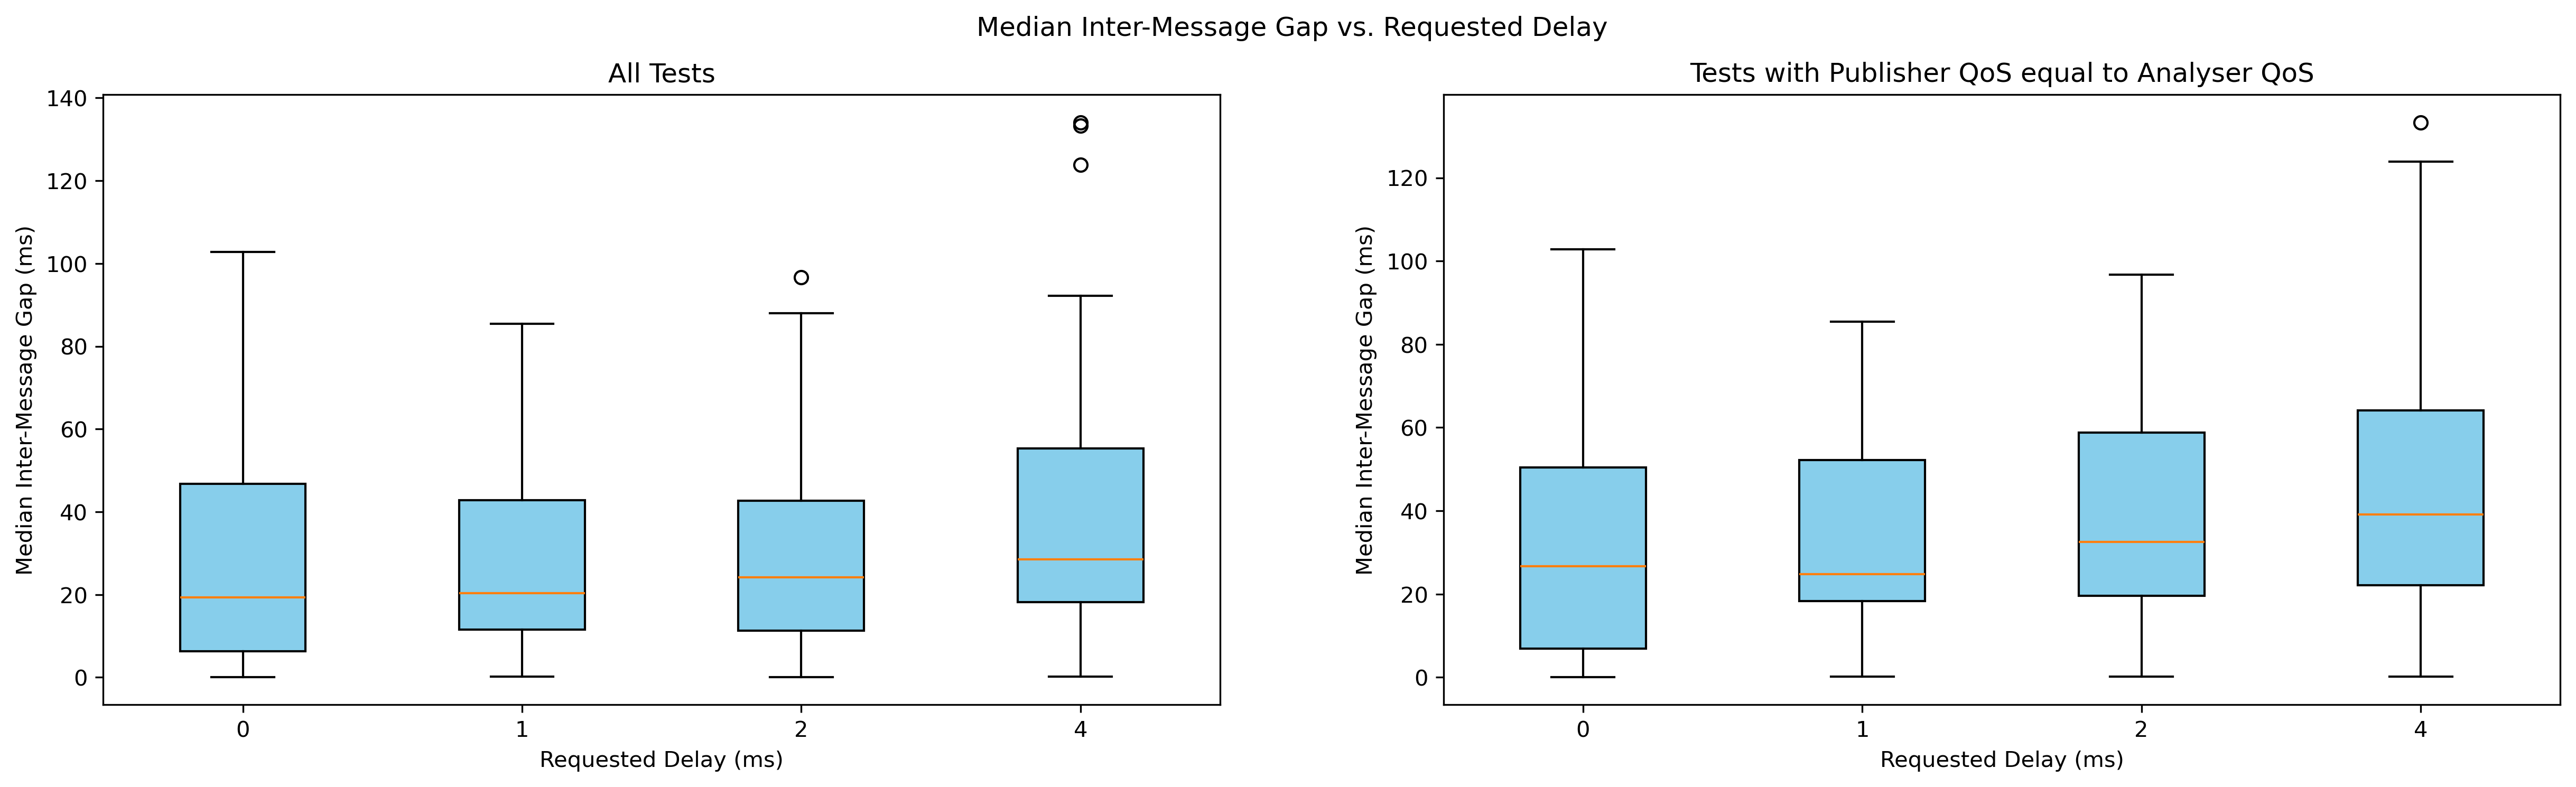

In [48]:
fig, axs = plt.subplots(1, 2, figsize=(20, 5), dpi=300)
dfs = [df, filtered_df]

for idx, ax in enumerate(axs):
    # Group data by 'qos' and collect the 'median_inter_message_gap' values
    grouped_data = [dfs[idx].loc[dfs[idx]['delay'] == instancecount, 'median_inter_message_gap'] for instancecount in [0, 1, 2, 4]]
    
    # Create a box plot
    ax.boxplot(grouped_data, labels=[0, 1, 2, 4], patch_artist=True, boxprops=dict(facecolor="skyblue"))
    ax.set_ylabel('Median Inter-Message Gap (ms)')
    ax.set_xlabel('Requested Delay (ms)')
    ax.set_title(labels[idx])
    ax.set_xticks([1, 2, 3, 4])  # Set the x-ticks to correspond to the QoS labels

plt.suptitle('Median Inter-Message Gap vs. Requested Delay')
plt.show()

## Instancecount

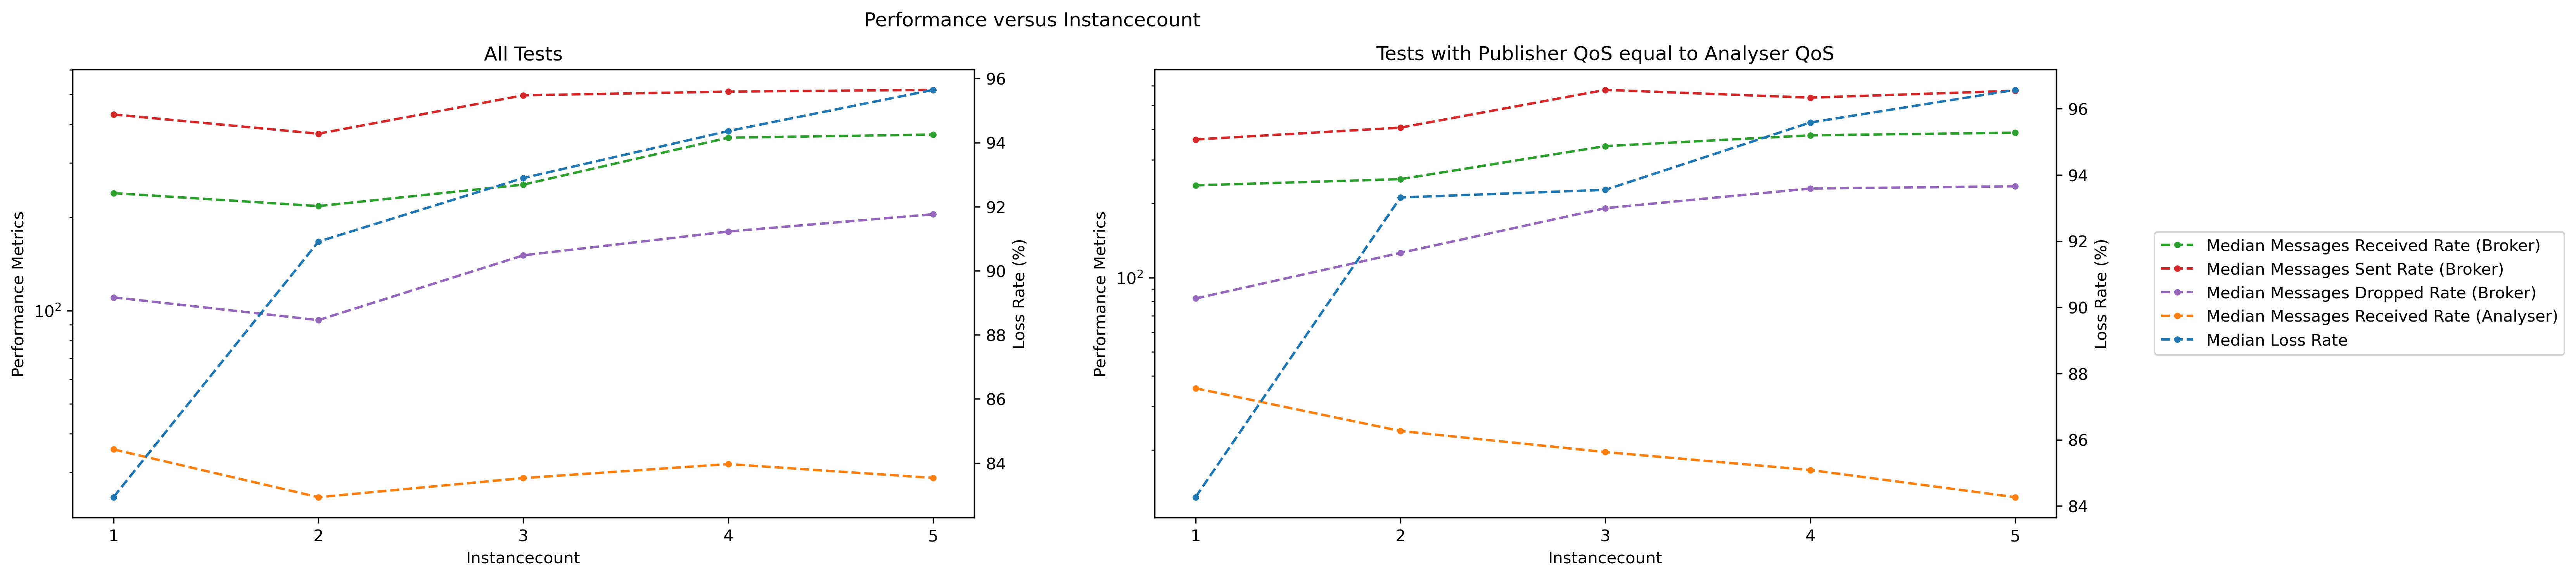

In [49]:
instancecount = [1,2,3,4,5]
dfs = [df,filtered_df]
fig, axs = plt.subplots(1,2,figsize=(22,5),dpi=300)

for idx,ax in enumerate(axs):
    loss_rate = [dfs[idx][dfs[idx]['instancecount'] == 1]['loss_rate'].median(),dfs[idx][dfs[idx]['instancecount'] == 2]['loss_rate'].median(),dfs[idx][dfs[idx]['instancecount'] == 3]['loss_rate'].median(),dfs[idx][dfs[idx]['instancecount'] == 4]['loss_rate'].median(),dfs[idx][dfs[idx]['instancecount'] == 5]['loss_rate'].median()]
    analyser_message_received = [dfs[idx][dfs[idx]['instancecount'] == 1]['received_rate'].median(),dfs[idx][dfs[idx]['instancecount'] == 2]['received_rate'].median(),dfs[idx][dfs[idx]['instancecount'] == 3]['received_rate'].median(),dfs[idx][dfs[idx]['instancecount'] == 4]['received_rate'].median(),dfs[idx][dfs[idx]['instancecount'] == 5]['received_rate'].median()]
    broker_messages_received = [dfs[idx][dfs[idx]['instancecount'] == 1]['$SYS/broker/load/messages/received/1min'].median(),dfs[idx][dfs[idx]['instancecount'] == 2]['$SYS/broker/load/messages/received/1min'].median(),dfs[idx][dfs[idx]['instancecount'] == 3]['$SYS/broker/load/messages/received/1min'].median(),dfs[idx][dfs[idx]['instancecount'] == 4]['$SYS/broker/load/messages/received/1min'].median(),dfs[idx][dfs[idx]['instancecount'] == 5]['$SYS/broker/load/messages/received/1min'].median()]
    broker_messages_sent = [dfs[idx][dfs[idx]['instancecount'] == 1]['$SYS/broker/load/messages/sent/1min'].median(),dfs[idx][dfs[idx]['instancecount'] == 2]['$SYS/broker/load/messages/sent/1min'].median(),dfs[idx][dfs[idx]['instancecount'] == 3]['$SYS/broker/load/messages/sent/1min'].median(),dfs[idx][dfs[idx]['instancecount'] == 4]['$SYS/broker/load/messages/sent/1min'].median(),dfs[idx][dfs[idx]['instancecount'] == 5]['$SYS/broker/load/messages/sent/1min'].median()]
    broker_messages_dropped = [dfs[idx][dfs[idx]['instancecount'] == 1]['$SYS/broker/load/publish/dropped/1min'].median(),dfs[idx][dfs[idx]['instancecount'] == 2]['$SYS/broker/load/publish/dropped/1min'].median(),dfs[idx][dfs[idx]['instancecount'] == 3]['$SYS/broker/load/publish/dropped/1min'].median(),dfs[idx][dfs[idx]['instancecount'] == 4]['$SYS/broker/load/publish/dropped/1min'].median(),dfs[idx][dfs[idx]['instancecount'] == 5]['$SYS/broker/load/publish/dropped/1min'].median()]
    ax.plot(instancecount, np.array(broker_messages_received)/60, color='C2', marker='.', linestyle='--', label='Median Messages Received Rate (Broker)')
    ax.plot(instancecount, np.array(broker_messages_sent)/60, color='C3', marker='.', linestyle='--', label='Median Messages Sent Rate (Broker)')
    ax.plot(instancecount, np.array(broker_messages_dropped)/60, color='C4', marker='.', linestyle='--', label='Median Messages Dropped Rate (Broker)')
    ax.plot(instancecount, analyser_message_received, color='C1', marker='.', linestyle='--', label='Median Messages Received Rate (Analyser)')
    ax2 = ax.twinx()
    ax2.plot(instancecount, loss_rate, color='C0', marker='.', linestyle='--', label='Median Loss Rate')
    ax.set_xlabel('Instancecount')
    ax.set_ylabel('Performance Metrics')
    ax.set_yscale('log')
    ax2.set_ylabel('Loss Rate (%)')
    plt.title(labels[idx])
    lines_1, labels_1 = ax.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    plt.xticks([1, 2, 3, 4, 5])

plt.legend(lines_1 + lines_2, labels_1 + labels_2,loc='center left', bbox_to_anchor=(1.1, 0.5))
plt.suptitle('Performance versus Instancecount')
plt.show()

## Publisher QOS

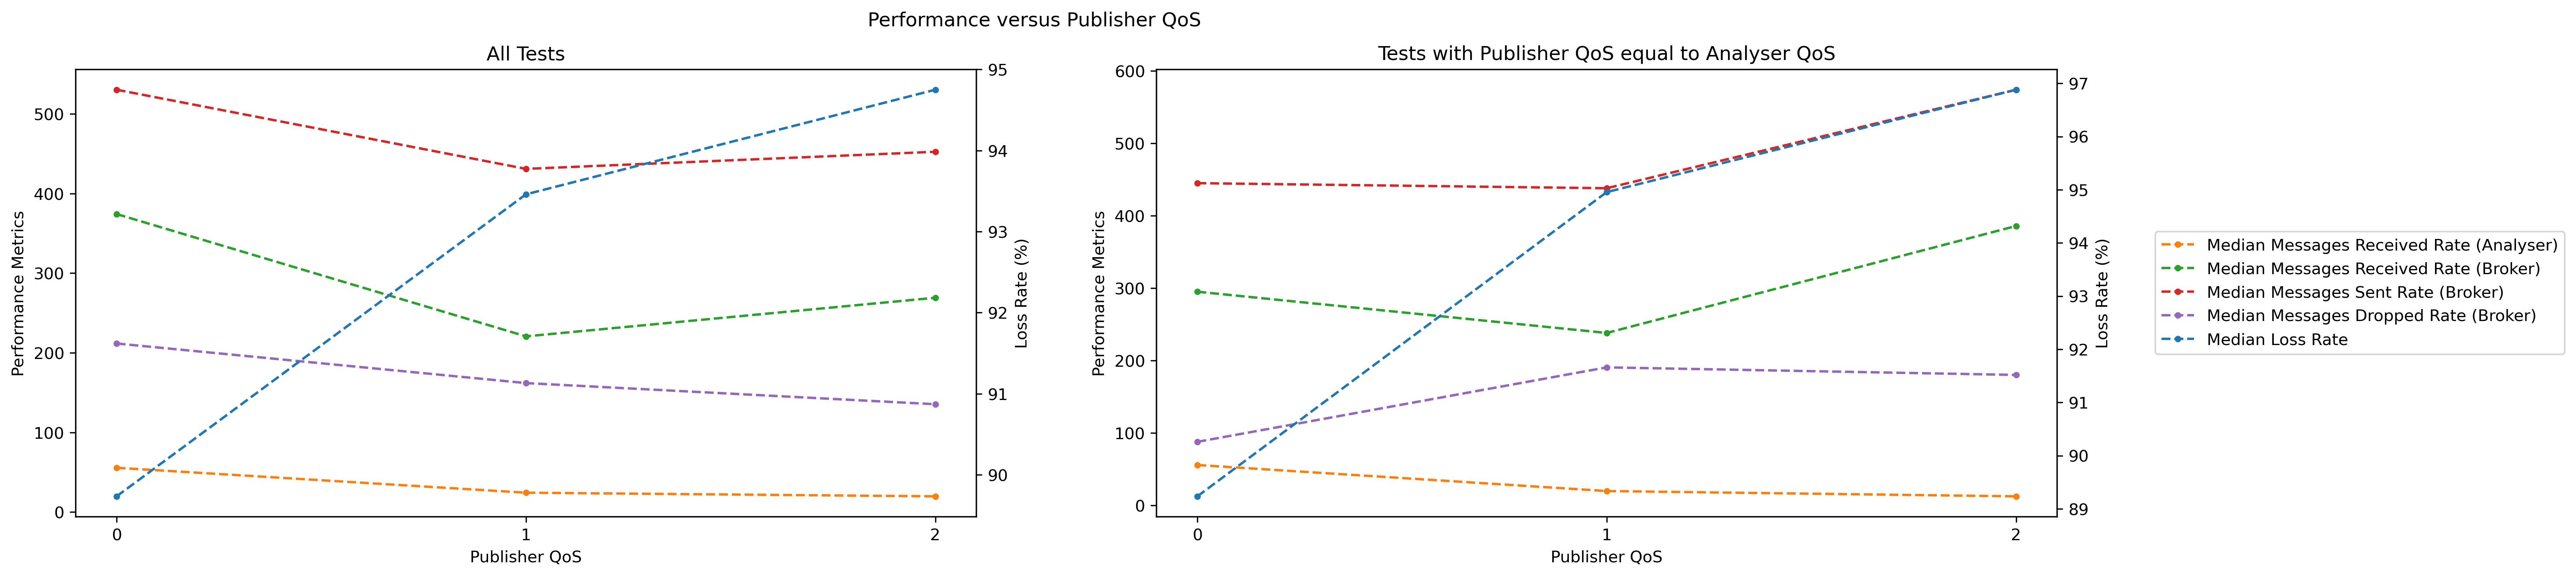

In [50]:
qos = [0,1,2]
dfs = [df,filtered_df]
fig, axs = plt.subplots(1,2,figsize=(22,5),dpi=300)

for idx,ax in enumerate(axs):
    loss_rate = [dfs[idx][dfs[idx]['qos'] == 0]['loss_rate'].median(),dfs[idx][dfs[idx]['qos'] == 1]['loss_rate'].median(),dfs[idx][dfs[idx]['qos'] == 2]['loss_rate'].median()]
    broker_messages_received = [dfs[idx][dfs[idx]['qos'] == 0]['$SYS/broker/load/messages/received/1min'].median(),dfs[idx][dfs[idx]['qos'] == 1]['$SYS/broker/load/messages/received/1min'].median(),dfs[idx][dfs[idx]['qos'] == 2]['$SYS/broker/load/messages/received/1min'].median()]
    broker_messages_sent = [dfs[idx][dfs[idx]['qos'] == 0]['$SYS/broker/load/messages/sent/1min'].median(),dfs[idx][dfs[idx]['qos'] == 1]['$SYS/broker/load/messages/sent/1min'].median(),dfs[idx][dfs[idx]['qos'] == 2]['$SYS/broker/load/messages/sent/1min'].median()]
    broker_messages_dropped = [dfs[idx][dfs[idx]['qos'] == 0]['$SYS/broker/load/publish/dropped/1min'].median(),dfs[idx][dfs[idx]['qos'] == 1]['$SYS/broker/load/publish/dropped/1min'].median(),dfs[idx][dfs[idx]['qos'] == 2]['$SYS/broker/load/publish/dropped/1min'].median()]
    analyser_message_received = [dfs[idx][dfs[idx]['qos'] == 0]['received_rate'].median(),dfs[idx][dfs[idx]['qos'] == 1]['received_rate'].median(),dfs[idx][dfs[idx]['qos'] == 2]['received_rate'].median()]

    ax.plot(qos, analyser_message_received, color='C1', marker='.', linestyle='--', label='Median Messages Received Rate (Analyser)')
    ax.plot(qos, np.array(broker_messages_received)/60, color='C2', marker='.', linestyle='--', label='Median Messages Received Rate (Broker)')
    ax.plot(qos, np.array(broker_messages_sent)/60, color='C3', marker='.', linestyle='--', label='Median Messages Sent Rate (Broker)')
    ax.plot(qos, np.array(broker_messages_dropped)/60, color='C4', marker='.', linestyle='--', label='Median Messages Dropped Rate (Broker)')
    ax2 = ax.twinx()
    ax2.plot(qos, loss_rate, color='C0', marker='.', linestyle='--', label='Median Loss Rate')
    ax.set_xlabel('Publisher QoS')
    ax.set_ylabel('Performance Metrics')
    # ax.set_yscale('log')
    ax2.set_ylabel('Loss Rate (%)')
    ax.set_title(labels[idx])
    lines_1, labels_1 = ax.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax.set_xticks([0,1,2])
plt.suptitle('Performance versus Publisher QoS')
ax.legend(lines_1 + lines_2, labels_1 + labels_2,loc='center left', bbox_to_anchor=(1.1, 0.5))
plt.show()

Broker receives pretty constant number of messages. But sends significantly less for higher QOS. Could be due to overhead of 4-way handshake. Also makes sense for it to send less

## Publisher Delay

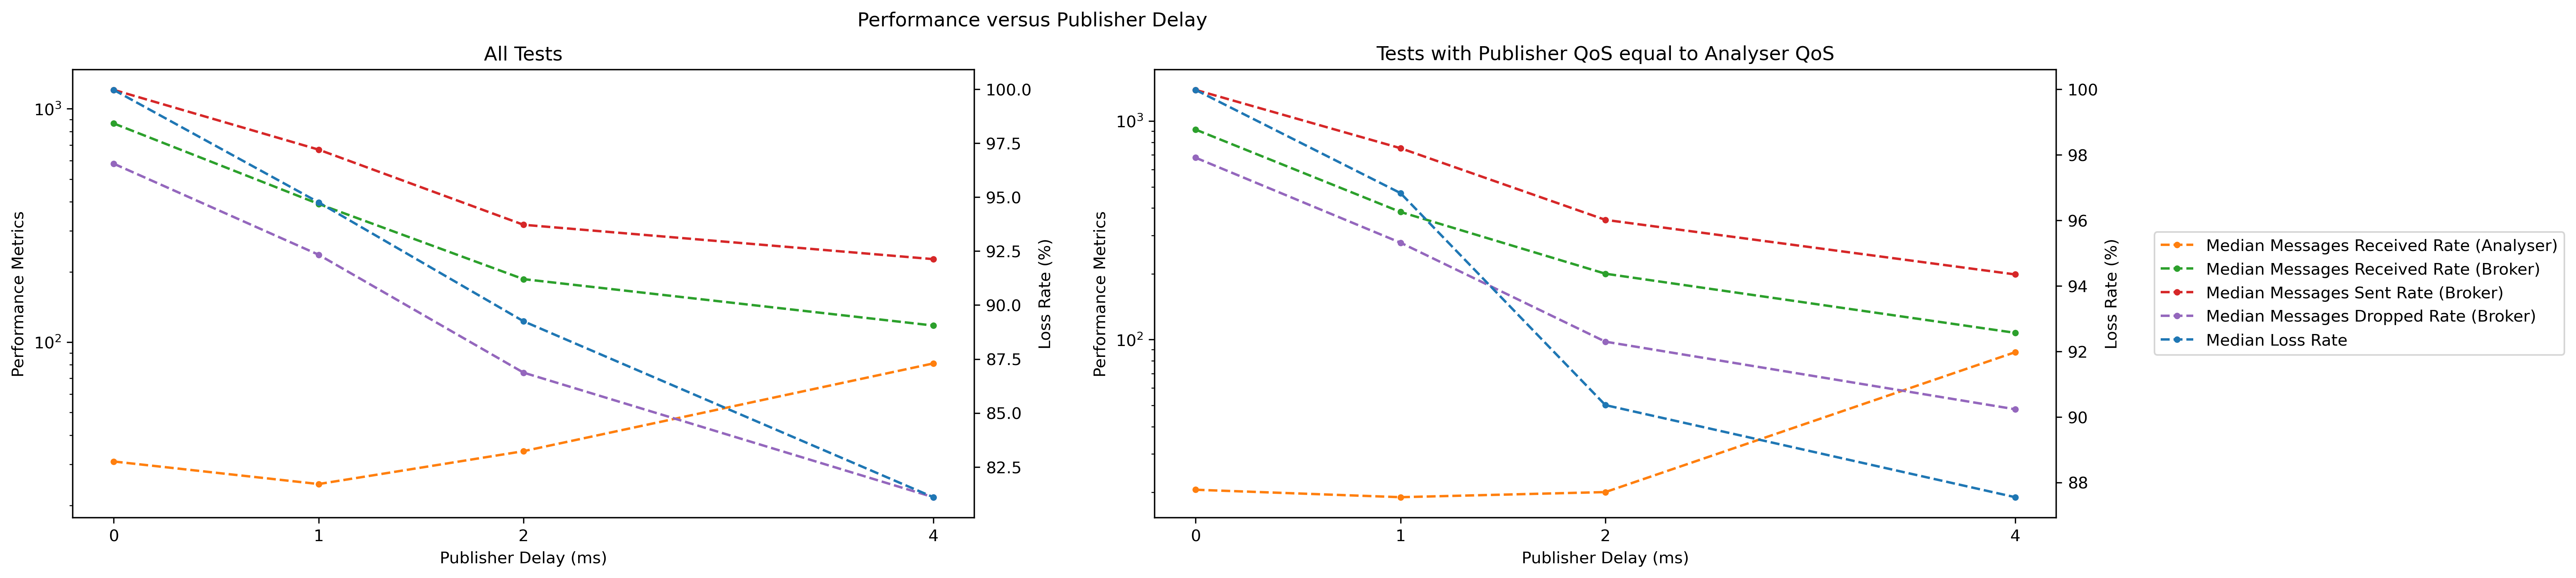

In [51]:
delay = [0,1,2,4]

dfs = [df,filtered_df]
fig, axs = plt.subplots(1,2,figsize=(22,5),dpi=300)

for idx,ax in enumerate(axs):
    loss_rate = [dfs[idx][dfs[idx]['delay'] == 0]['loss_rate'].median(),dfs[idx][dfs[idx]['delay'] == 1]['loss_rate'].median(),dfs[idx][dfs[idx]['delay'] == 2]['loss_rate'].median(),dfs[idx][dfs[idx]['delay'] == 4]['loss_rate'].median()]
    broker_messages_received = [dfs[idx][dfs[idx]['delay'] == 0]['$SYS/broker/load/messages/received/1min'].median(),dfs[idx][dfs[idx]['delay'] == 1]['$SYS/broker/load/messages/received/1min'].median(),dfs[idx][dfs[idx]['delay'] == 2]['$SYS/broker/load/messages/received/1min'].median(),dfs[idx][dfs[idx]['delay'] == 4]['$SYS/broker/load/messages/received/1min'].median()]
    broker_messages_sent = [dfs[idx][dfs[idx]['delay'] == 0]['$SYS/broker/load/messages/sent/1min'].median(),dfs[idx][dfs[idx]['delay'] == 1]['$SYS/broker/load/messages/sent/1min'].median(),dfs[idx][dfs[idx]['delay'] == 2]['$SYS/broker/load/messages/sent/1min'].median(),dfs[idx][dfs[idx]['delay'] == 4]['$SYS/broker/load/messages/sent/1min'].median()]
    broker_messages_dropped = [dfs[idx][dfs[idx]['delay'] == 0]['$SYS/broker/load/publish/dropped/1min'].median(),dfs[idx][dfs[idx]['delay'] == 1]['$SYS/broker/load/publish/dropped/1min'].median(),dfs[idx][dfs[idx]['delay'] == 2]['$SYS/broker/load/publish/dropped/1min'].median(),dfs[idx][dfs[idx]['delay'] == 4]['$SYS/broker/load/publish/dropped/1min'].median()]
    analyser_message_received = [dfs[idx][dfs[idx]['delay'] == 0]['received_rate'].median(),dfs[idx][dfs[idx]['delay'] == 1]['received_rate'].median(),dfs[idx][dfs[idx]['delay'] == 2]['received_rate'].median(),dfs[idx][dfs[idx]['delay'] == 4]['loss_rate'].median()]

    ax.plot(delay, analyser_message_received, color='C1', marker='.', linestyle='--', label='Median Messages Received Rate (Analyser)')
    ax.plot(delay, np.array(broker_messages_received)/60, color='C2', marker='.', linestyle='--', label='Median Messages Received Rate (Broker)')
    ax.plot(delay, np.array(broker_messages_sent)/60, color='C3', marker='.', linestyle='--', label='Median Messages Sent Rate (Broker)')
    ax.plot(delay, np.array(broker_messages_dropped)/60, color='C4', marker='.', linestyle='--', label='Median Messages Dropped Rate (Broker)')
    ax.set_yscale('log')
    ax2 = ax.twinx()
    ax2.plot(delay, loss_rate, color='C0', marker='.', linestyle='--', label='Median Loss Rate')
    ax.set_xlabel('Publisher Delay (ms)')
    ax.set_ylabel('Performance Metrics')
    ax2.set_ylabel('Loss Rate (%)')
    ax.set_title(labels[idx])
    lines_1, labels_1 = ax.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax.set_xticks([0,1,2,4])
plt.suptitle('Performance versus Publisher Delay')
ax.legend(lines_1 + lines_2, labels_1 + labels_2,loc='center left', bbox_to_anchor=(1.1, 0.5))
plt.show()

We can see longer delay requests reduce loss rate, indicating improved performance from the broker. Loss is still quite very high for the maximum delay case (4ms). Suggests the tested network configuration is not capable of such data rates.

## Delay

### Requested delay versus Observed Delay

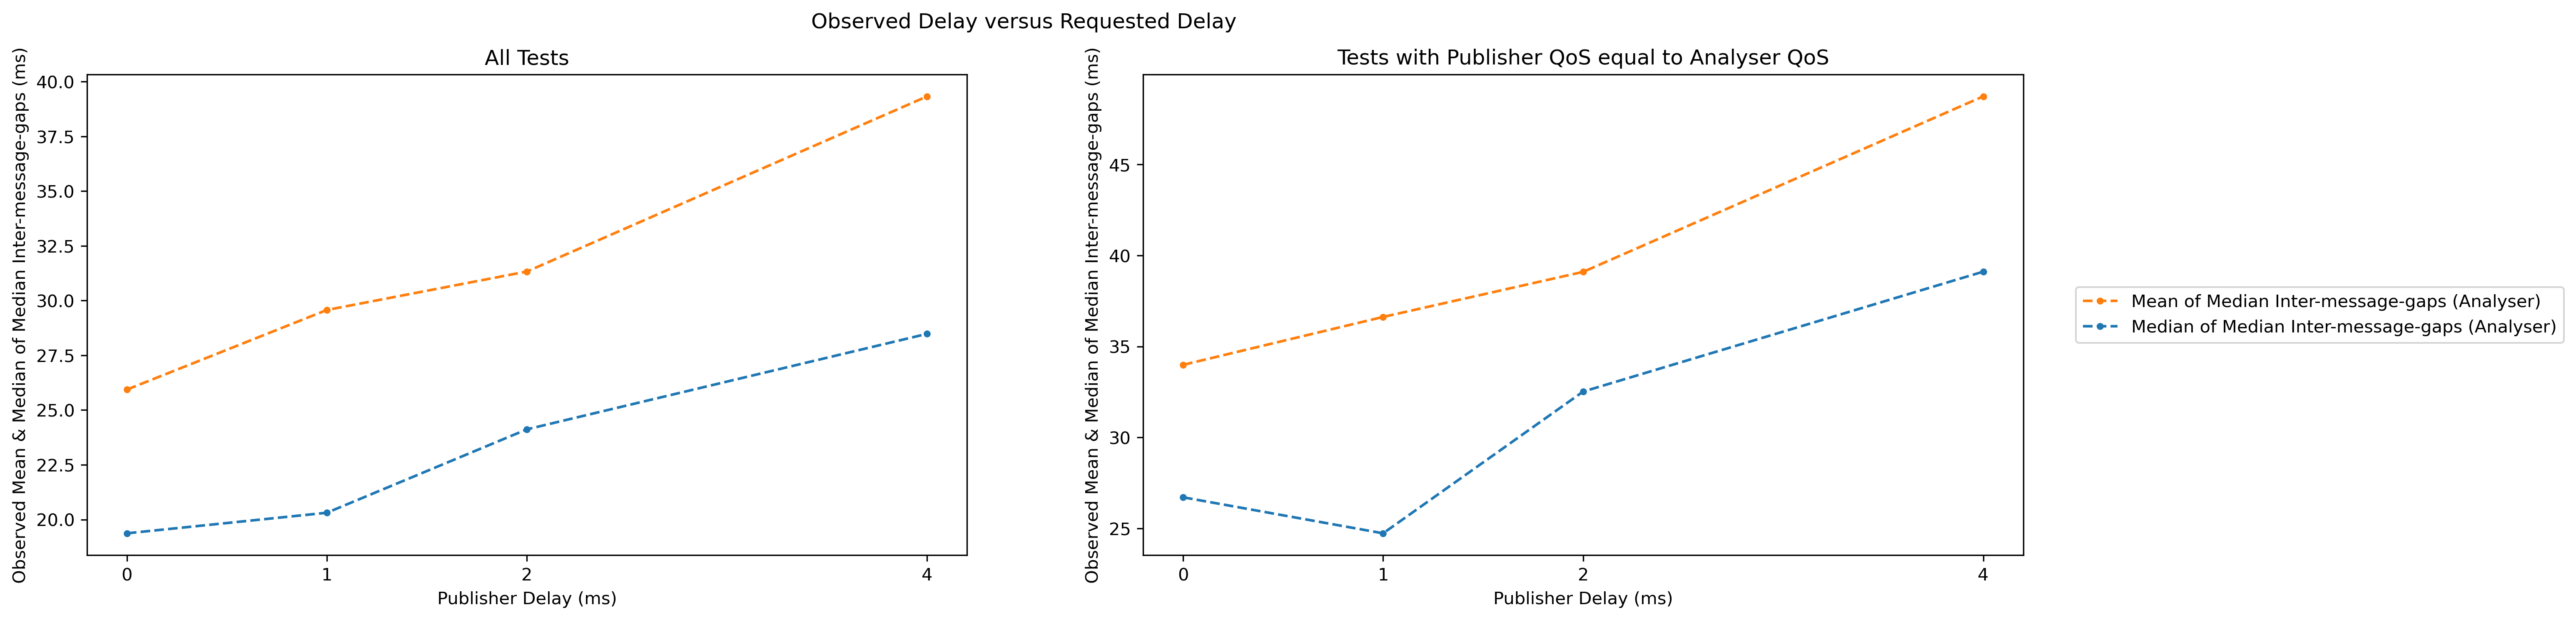

In [52]:
delay = [0,1,2,4]

dfs = [df,filtered_df]
fig, axs = plt.subplots(1,2,figsize=(20,5),dpi=300)

for idx,ax in enumerate(axs):
    median_observed_delay = [dfs[idx][dfs[idx]['delay'] == 0]['median_inter_message_gap'].median(),dfs[idx][dfs[idx]['delay'] == 1]['median_inter_message_gap'].median(),dfs[idx][dfs[idx]['delay'] == 2]['median_inter_message_gap'].median(),dfs[idx][dfs[idx]['delay'] == 4]['median_inter_message_gap'].median()]
    mean_observed_delay = [dfs[idx][dfs[idx]['delay'] == 0]['median_inter_message_gap'].mean(),dfs[idx][dfs[idx]['delay'] == 1]['median_inter_message_gap'].mean(),dfs[idx][dfs[idx]['delay'] == 2]['median_inter_message_gap'].mean(),dfs[idx][dfs[idx]['delay'] == 4]['median_inter_message_gap'].mean()]


    ax.plot(delay, mean_observed_delay, color='C1', marker='.', linestyle='--', label='Mean of Median Inter-message-gaps (Analyser)')
    ax.plot(delay, median_observed_delay, color='C0', marker='.', linestyle='--', label='Median of Median Inter-message-gaps (Analyser)')
    ax.set_xlabel('Publisher Delay (ms)')
    ax.set_ylabel('Observed Mean & Median of Median Inter-message-gaps (ms)')
    ax.set_title(labels[idx])
    ax.set_xticks([0,1,2,4])
plt.suptitle('Observed Delay versus Requested Delay')
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.show()

A somewhat linear relationship. But the observed delay is always significantly longer than the request delay. If we consider the observed delay for requested delay 0 to be the minimum time required to traverse the network and treat this as a calibration error that must be undone, we get an observed delay much closer to the requested delay.

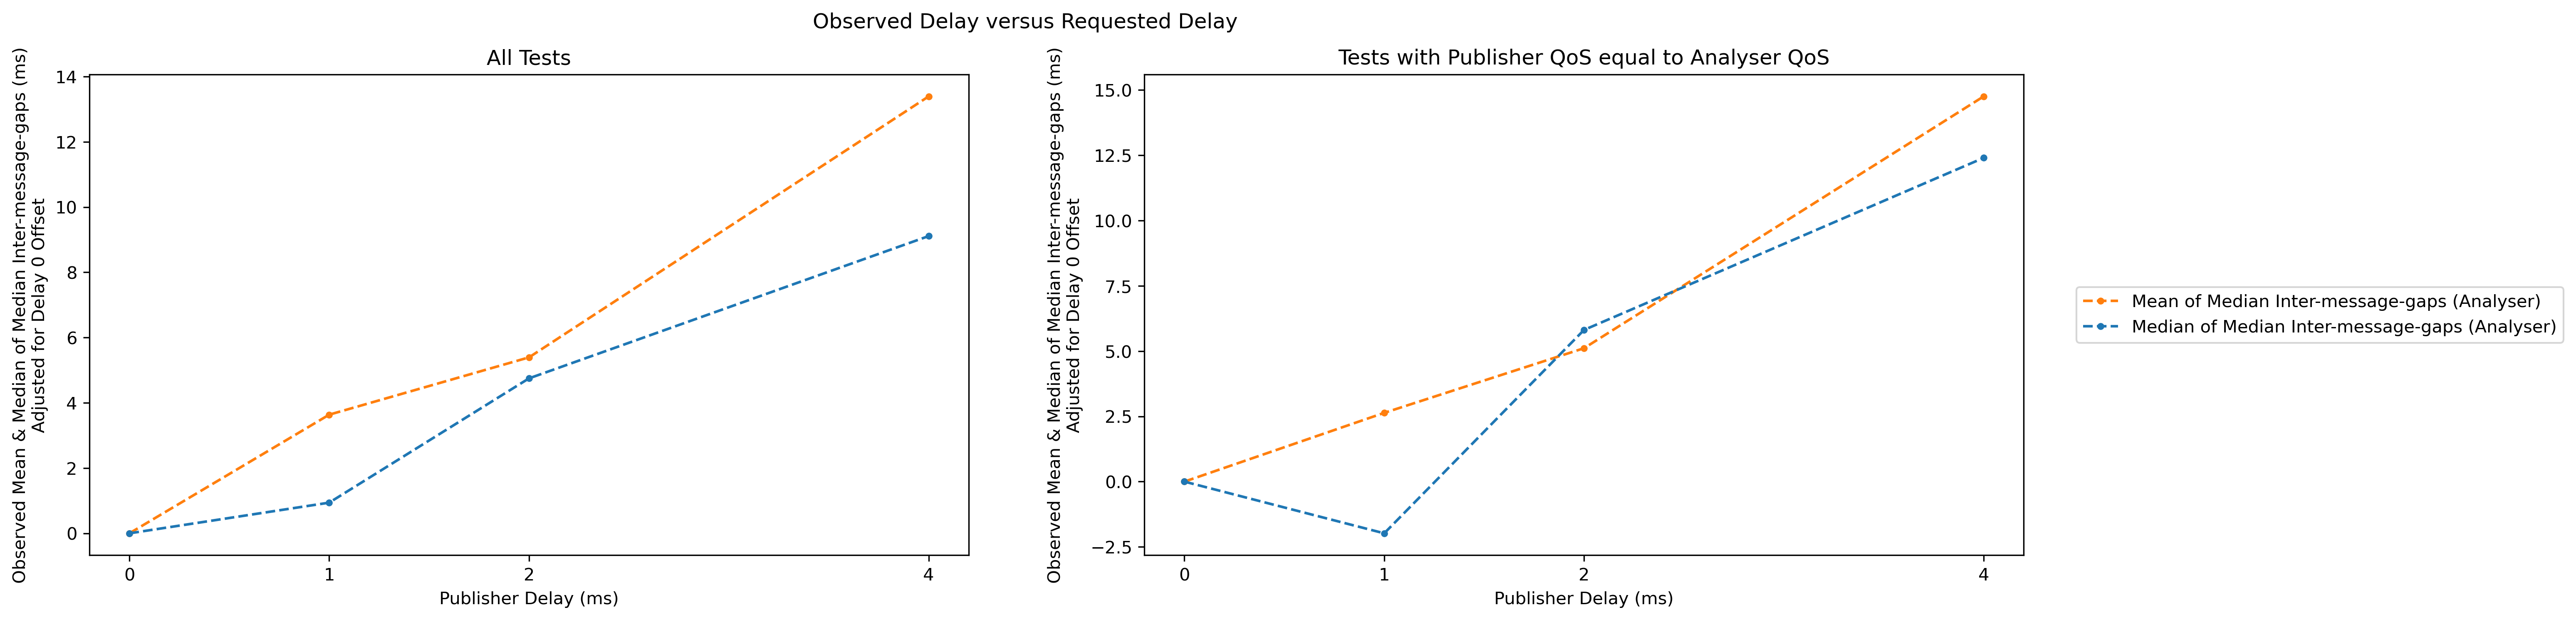

In [53]:
delay = [0,1,2,4]
dfs = [df,filtered_df]
fig, axs = plt.subplots(1,2,figsize=(20,5),dpi=300)

for idx,ax in enumerate(axs):
    median_observed_delay = [dfs[idx][dfs[idx]['delay'] == 0]['median_inter_message_gap'].median(),dfs[idx][dfs[idx]['delay'] == 1]['median_inter_message_gap'].median(),dfs[idx][dfs[idx]['delay'] == 2]['median_inter_message_gap'].median(),dfs[idx][dfs[idx]['delay'] == 4]['median_inter_message_gap'].median()]
    mean_observed_delay = [dfs[idx][dfs[idx]['delay'] == 0]['median_inter_message_gap'].mean(),dfs[idx][dfs[idx]['delay'] == 1]['median_inter_message_gap'].mean(),dfs[idx][dfs[idx]['delay'] == 2]['median_inter_message_gap'].mean(),dfs[idx][dfs[idx]['delay'] == 4]['median_inter_message_gap'].mean()]
    ax.plot(delay, mean_observed_delay-mean_observed_delay[0], color='C1', marker='.', linestyle='--', label='Mean of Median Inter-message-gaps (Analyser)')
    ax.plot(delay, median_observed_delay-median_observed_delay[0], color='C0', marker='.', linestyle='--', label='Median of Median Inter-message-gaps (Analyser)')
    ax.set_xlabel('Publisher Delay (ms)')
    ax.set_ylabel('Observed Mean & Median of Median Inter-message-gaps (ms)\nAdjusted for Delay 0 Offset')
    ax.set_xticks([0,1,2,4])
    ax.set_title(labels[idx])
plt.suptitle('Observed Delay versus Requested Delay')
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.show()

In this case we can see from the median values we're getting approx. twice the requested delay + network traversal offset

### Median Delay versus Broker Load

Assume broker dropping messages means broker is under more stress). Intention is to correlate long delays with broker under stress.

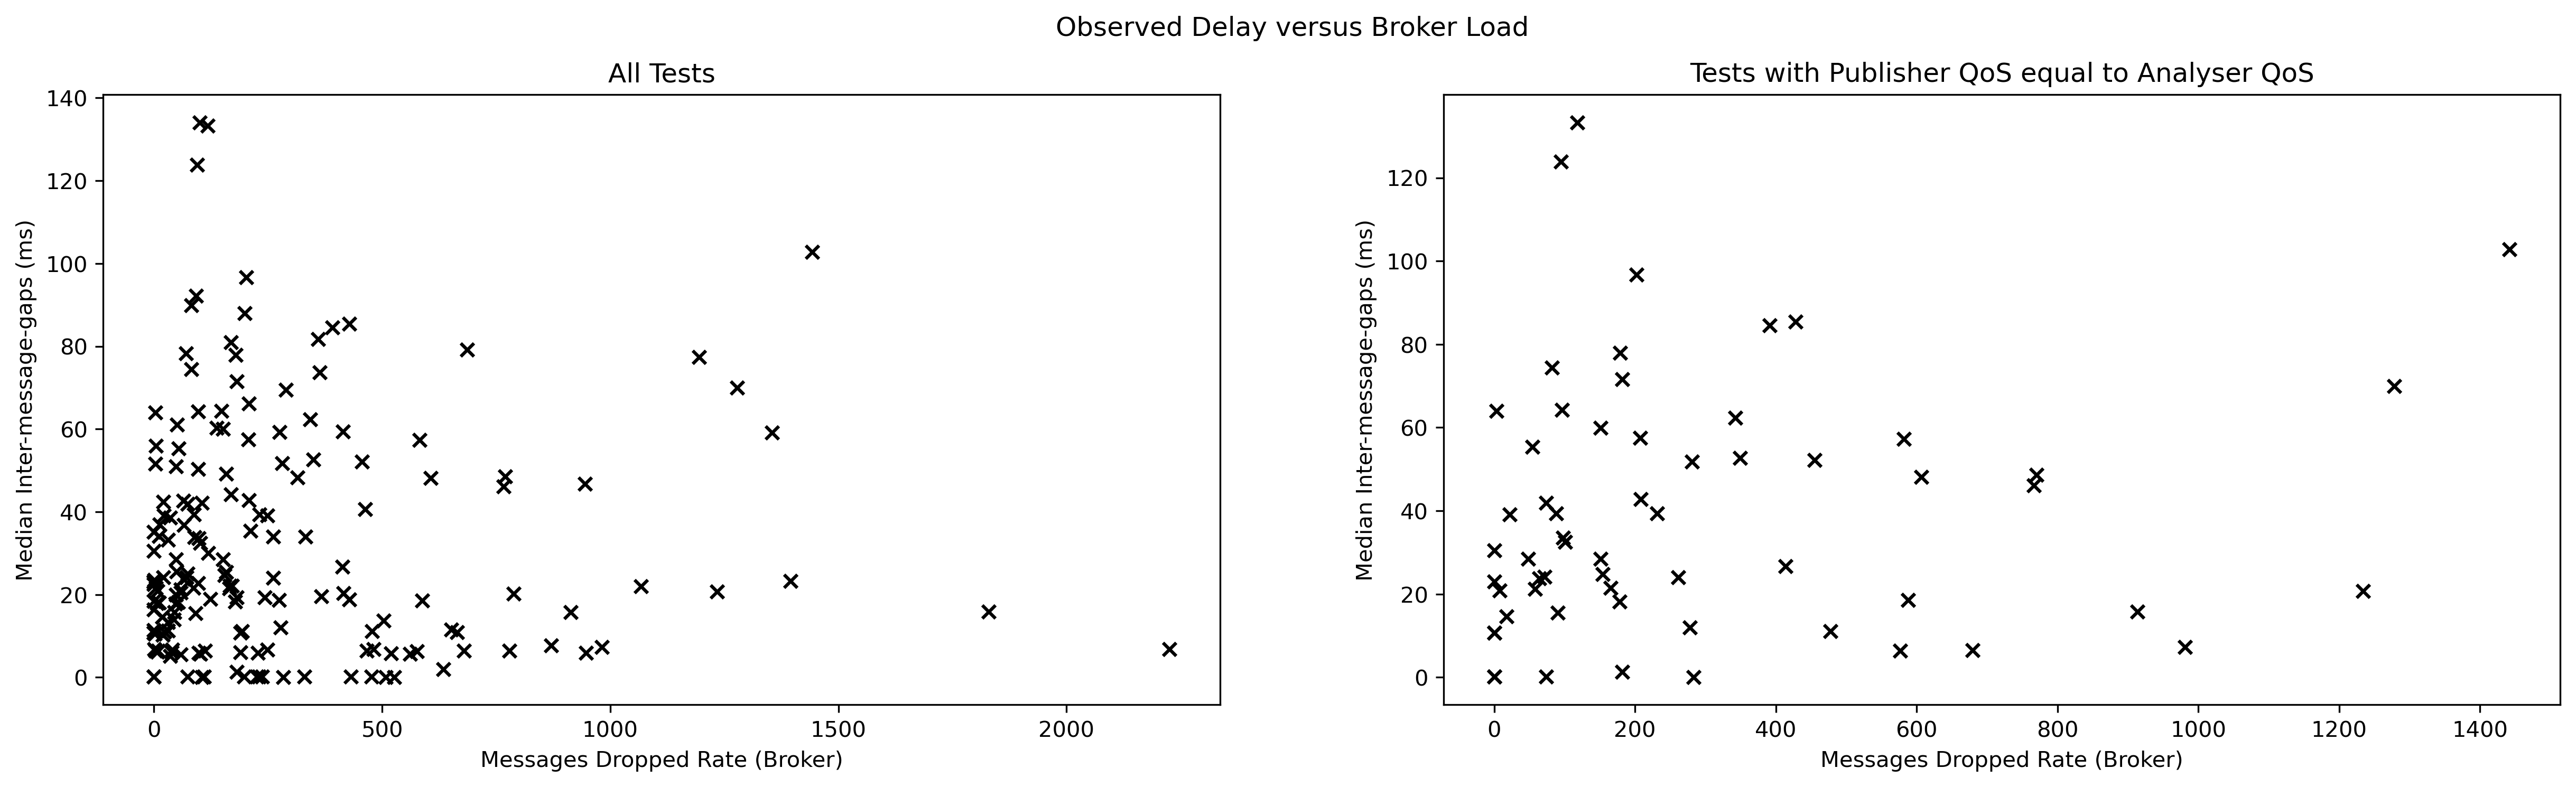

In [54]:
dfs = [df,filtered_df]
fig, axs = plt.subplots(1,2,figsize=(20,5),dpi=300)

for idx,ax in enumerate(axs):
    median_observed_delay = dfs[idx]['median_inter_message_gap']
    broker_messages_dropped = np.array(dfs[idx]['$SYS/broker/load/publish/dropped/1min'])/60

    ax.scatter(broker_messages_dropped, median_observed_delay, color='black', marker='x')
    ax.set_xlabel('Messages Dropped Rate (Broker)')
    ax.set_ylabel('Median Inter-message-gaps (ms)')
    ax.set_title(labels[idx])
plt.suptitle('Observed Delay versus Broker Load')
plt.show()

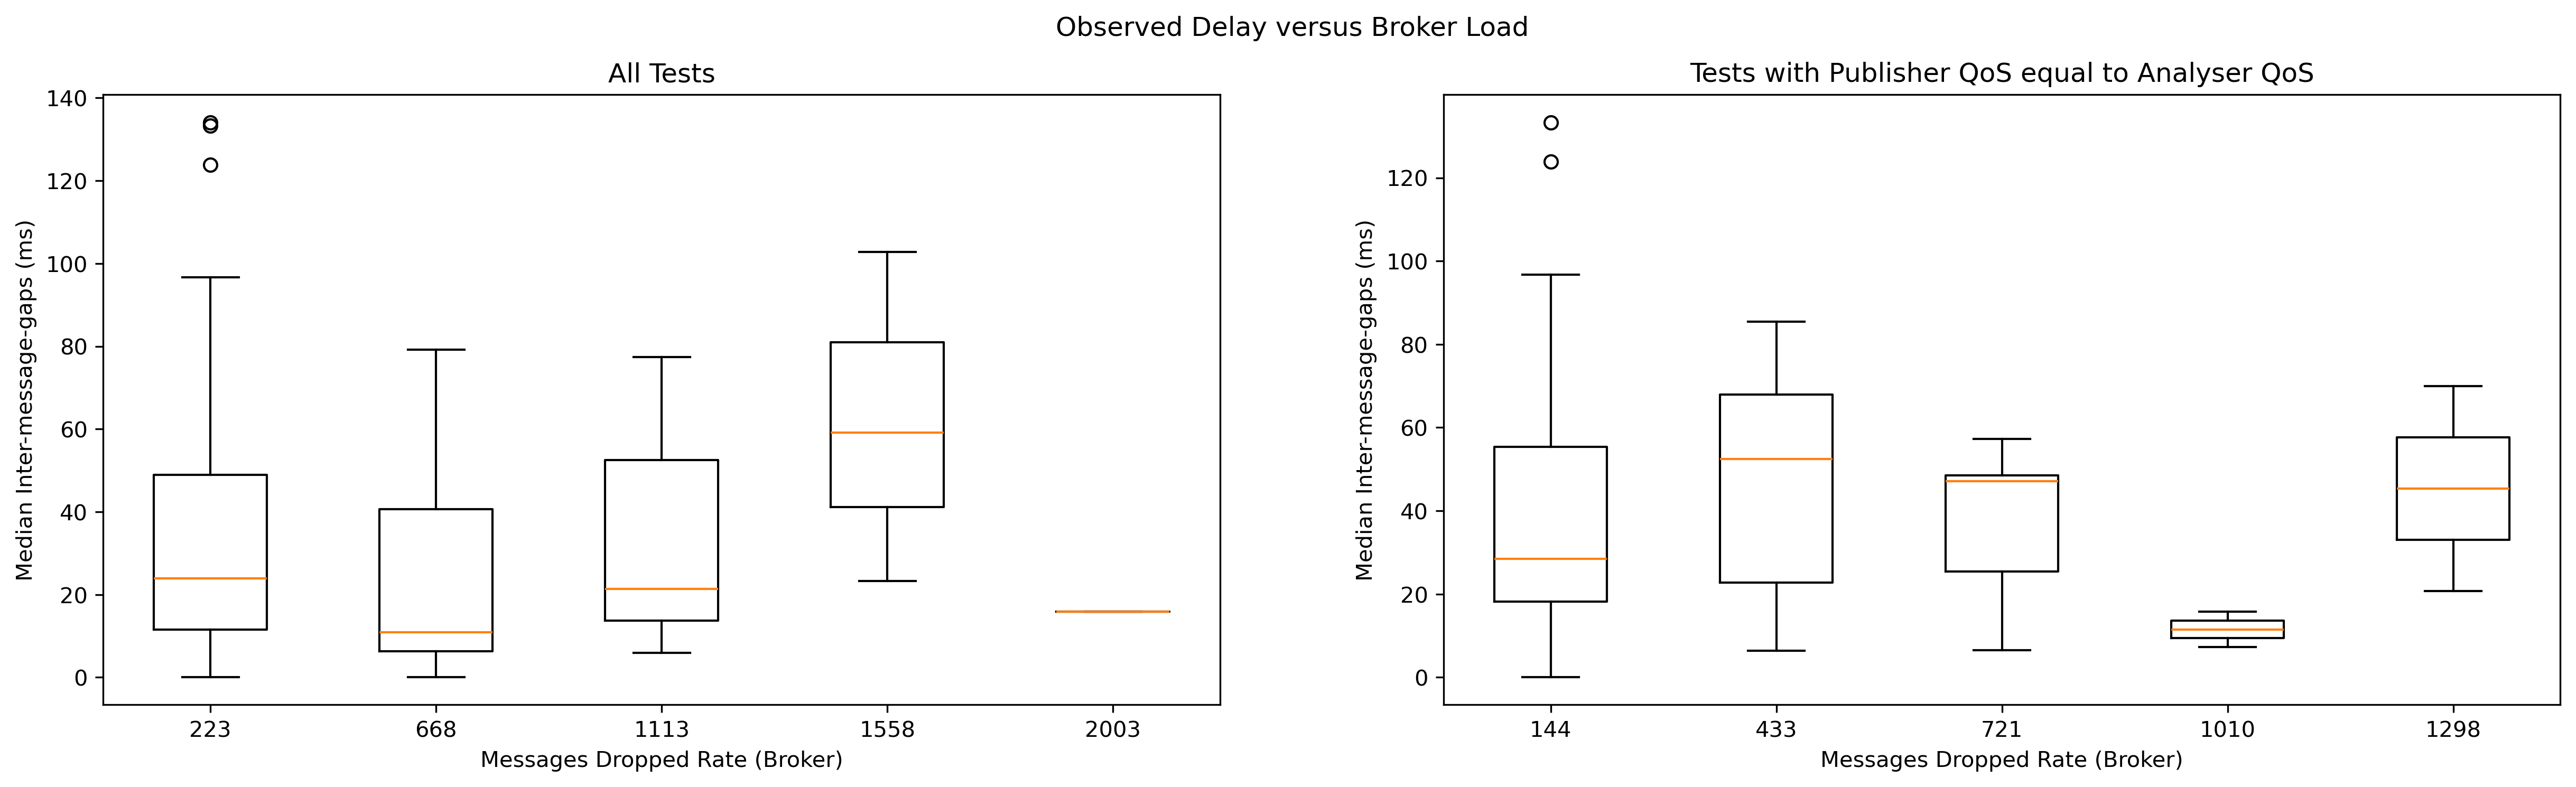

In [55]:
n = 5  # Tuneable number of bins

fig, axs = plt.subplots(1, 2, figsize=(20, 5), dpi=300)

for idx, ax in enumerate(axs):
    median_observed_delay = dfs[idx]['median_inter_message_gap']
    broker_messages_dropped = np.array(dfs[idx]['$SYS/broker/load/publish/dropped/1min']) / 60

    # Creating bins
    bins = np.linspace(broker_messages_dropped.min(), broker_messages_dropped.max(), n + 1)
    bin_labels = np.digitize(broker_messages_dropped, bins) - 1

    # Grouping data into bins
    binned_data = [median_observed_delay[bin_labels == i] for i in range(n)]

    # Plotting boxplot
    ax.boxplot(binned_data, positions=(bins[:-1] + bins[1:]) / 2, widths=np.diff(bins) / 2)
    ax.set_xticks([bins[i]+(bins[i+1]-bins[i])/2 for i in range(n)])
    ax.set_xticklabels([f"{round(bins[i]+(bins[i+1]-bins[i])/2)}" for i in range(n)])
    # ax.set_xticklabels([f'{bins[i]:.1f}' for i in range(n)], rotation=45)

    ax.set_xlabel('Messages Dropped Rate (Broker)')
    ax.set_ylabel('Median Inter-message-gaps (ms)')
    ax.set_title(labels[idx])

plt.suptitle('Observed Delay versus Broker Load')
plt.show()


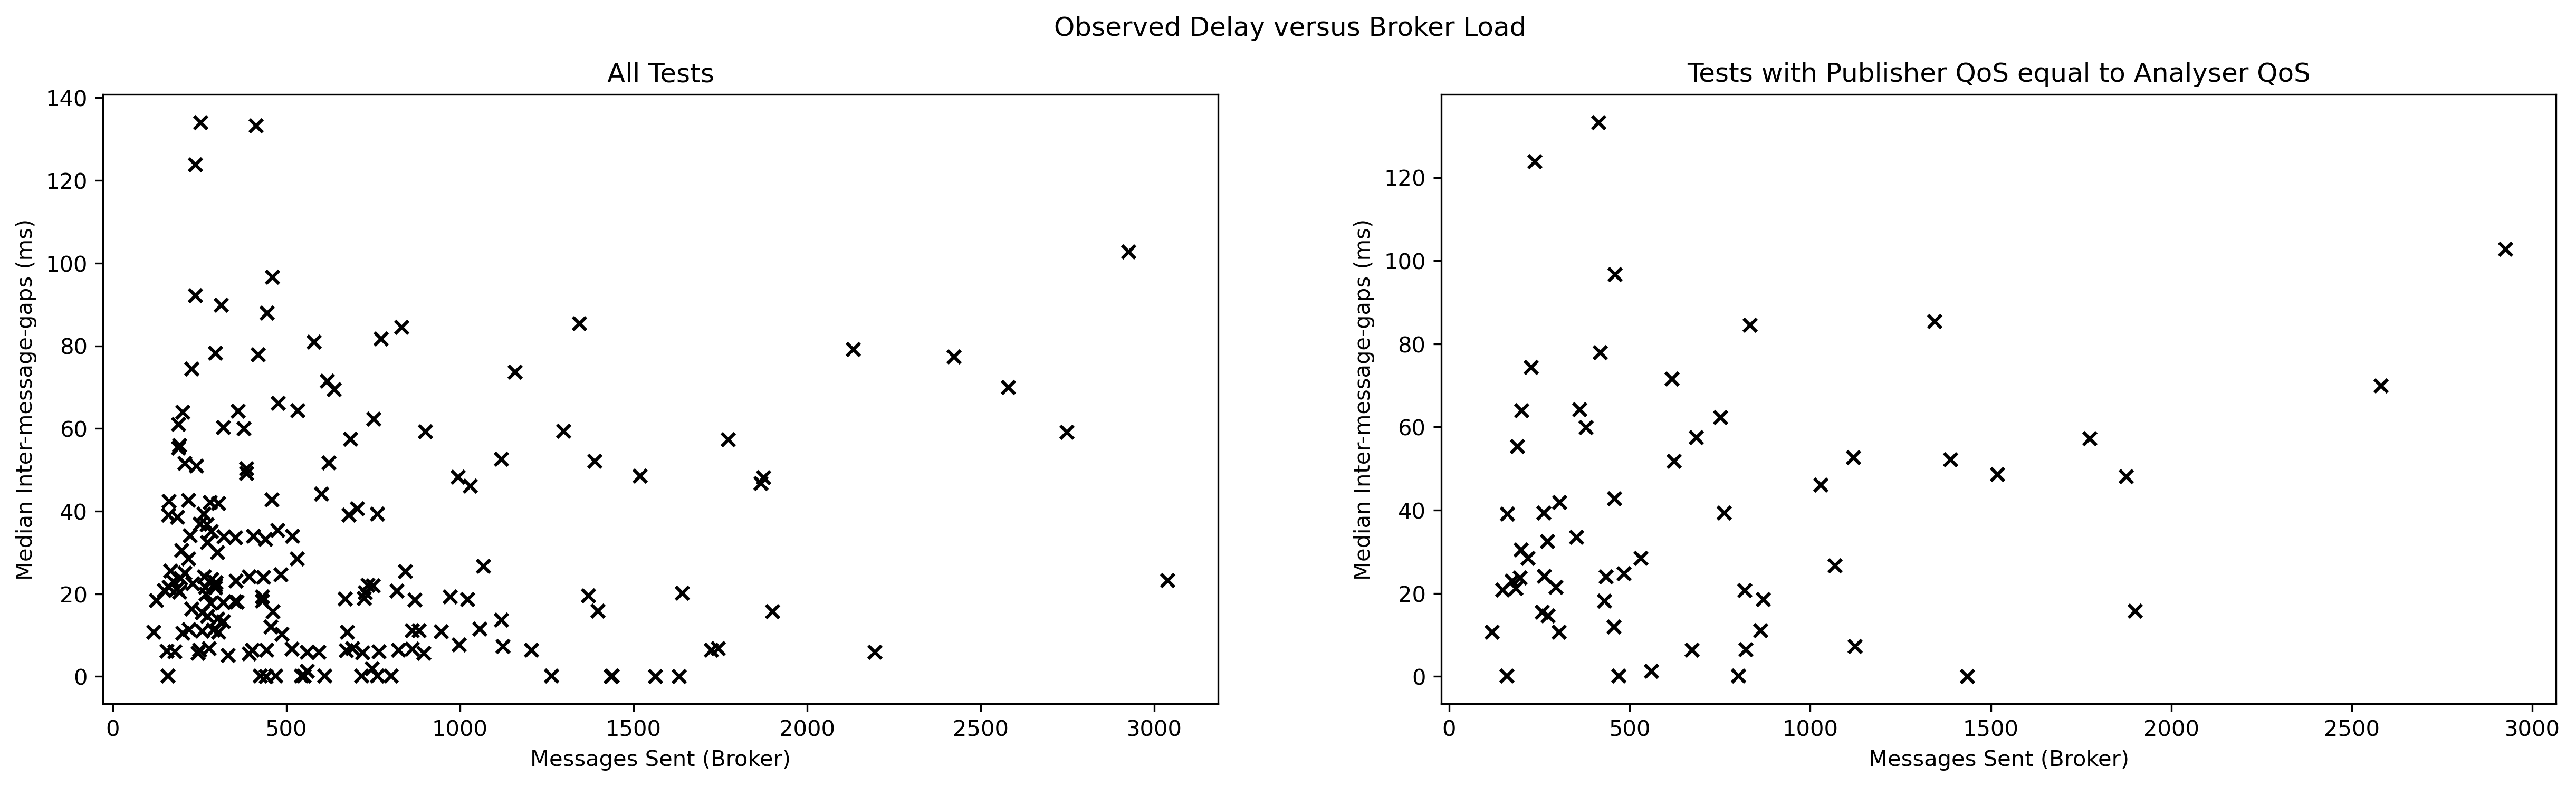

In [56]:
dfs = [df,filtered_df]
fig, axs = plt.subplots(1,2,figsize=(20,5),dpi=300)

for idx,ax in enumerate(axs):
    median_observed_delay = dfs[idx]['median_inter_message_gap']
    broker_messages_sent = np.array(dfs[idx]['$SYS/broker/load/messages/sent/1min'])/60

    ax.scatter(broker_messages_sent, median_observed_delay, color='black', marker='x')
    ax.set_xlabel('Messages Sent (Broker)')
    ax.set_ylabel('Median Inter-message-gaps (ms)')
    ax.set_title(labels[idx])
plt.suptitle('Observed Delay versus Broker Load')
plt.show()

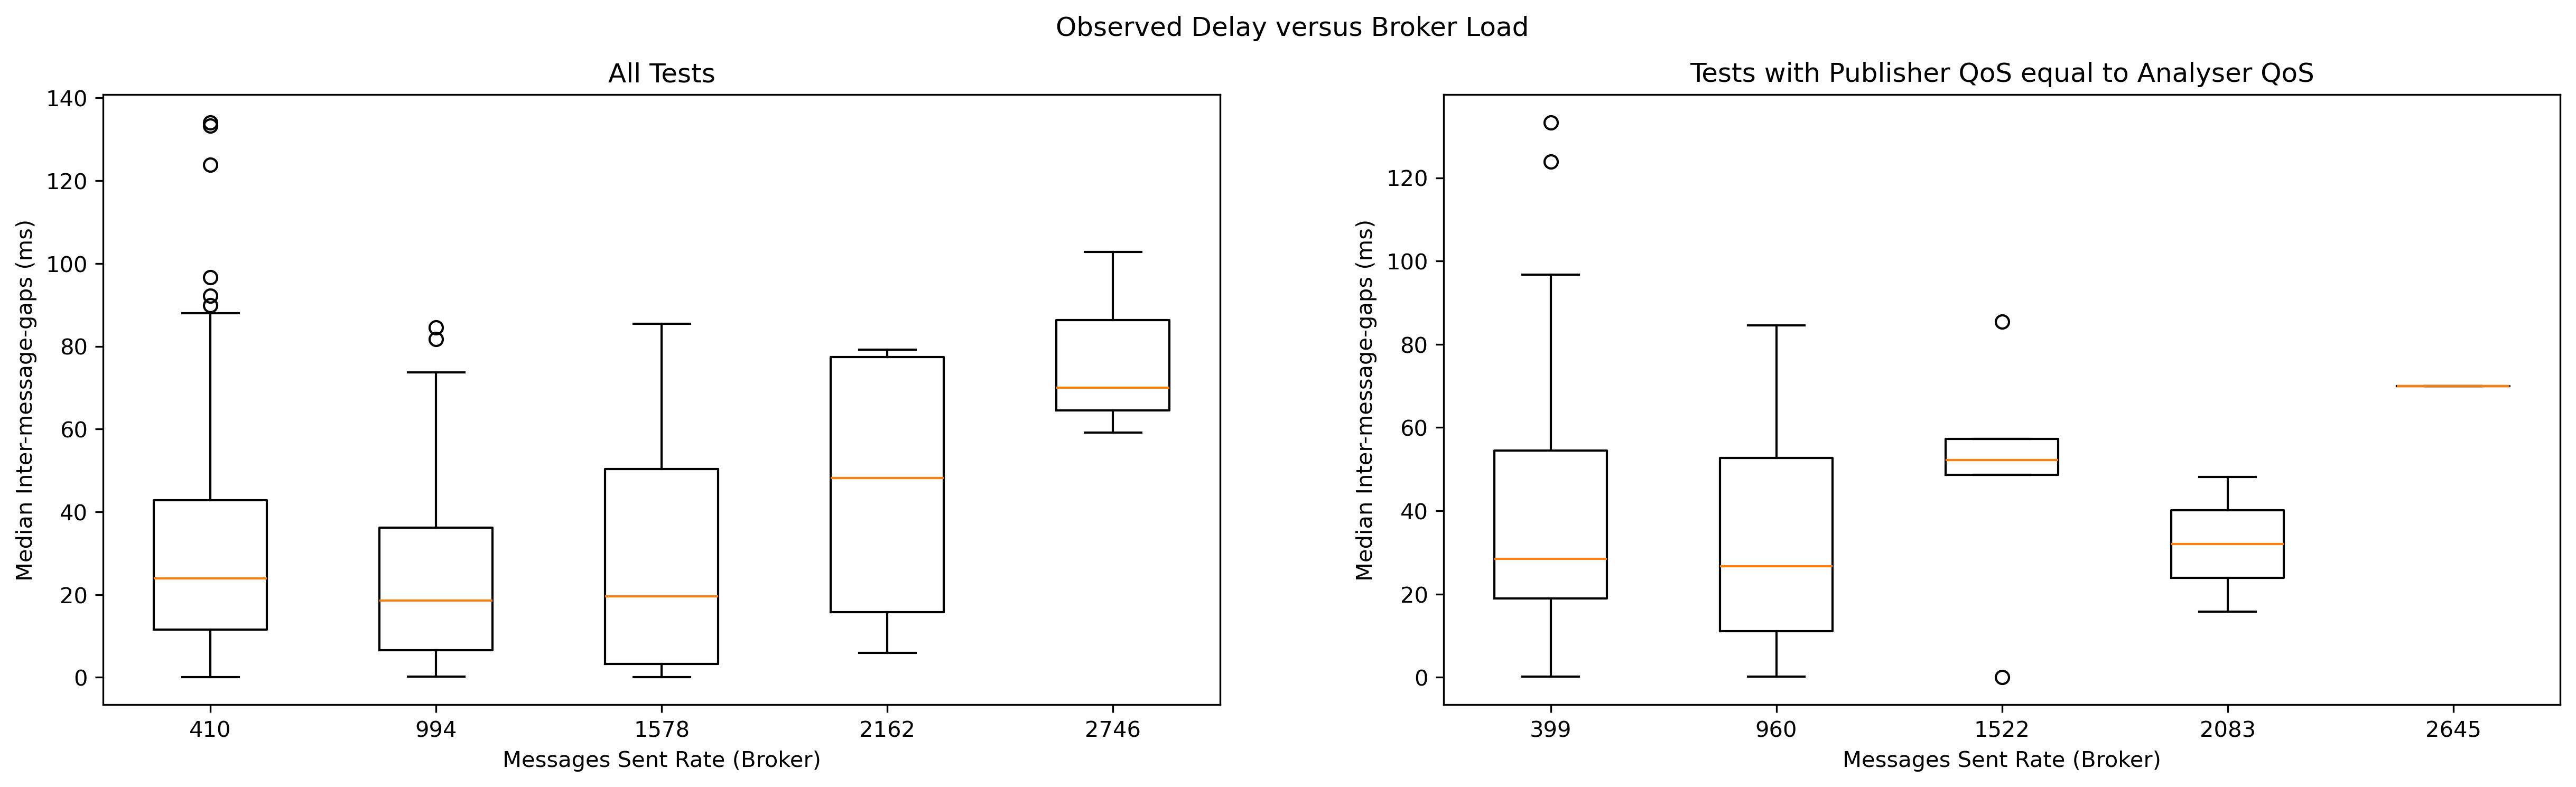

In [57]:
n = 5  # Tuneable number of bins

fig, axs = plt.subplots(1, 2, figsize=(20, 5), dpi=300)

for idx, ax in enumerate(axs):
    median_observed_delay = dfs[idx]['median_inter_message_gap']
    broker_messages_dropped = np.array(dfs[idx]['$SYS/broker/load/messages/sent/1min']) / 60

    # Creating bins
    bins = np.linspace(broker_messages_dropped.min(), broker_messages_dropped.max(), n + 1)
    bin_labels = np.digitize(broker_messages_dropped, bins) - 1

    # Grouping data into bins
    binned_data = [median_observed_delay[bin_labels == i] for i in range(n)]

    # Plotting boxplot
    ax.boxplot(binned_data, positions=(bins[:-1] + bins[1:]) / 2, widths=np.diff(bins) / 2)
    ax.set_xticks([bins[i]+(bins[i+1]-bins[i])/2 for i in range(n)])
    ax.set_xticklabels([f"{round(bins[i]+(bins[i+1]-bins[i])/2)}" for i in range(n)])
    # ax.set_xticklabels([f'{bins[i]:.1f}' for i in range(n)], rotation=45)

    ax.set_xlabel('Messages Sent Rate (Broker)')
    ax.set_ylabel('Median Inter-message-gaps (ms)')
    ax.set_title(labels[idx])

plt.suptitle('Observed Delay versus Broker Load')
plt.show()

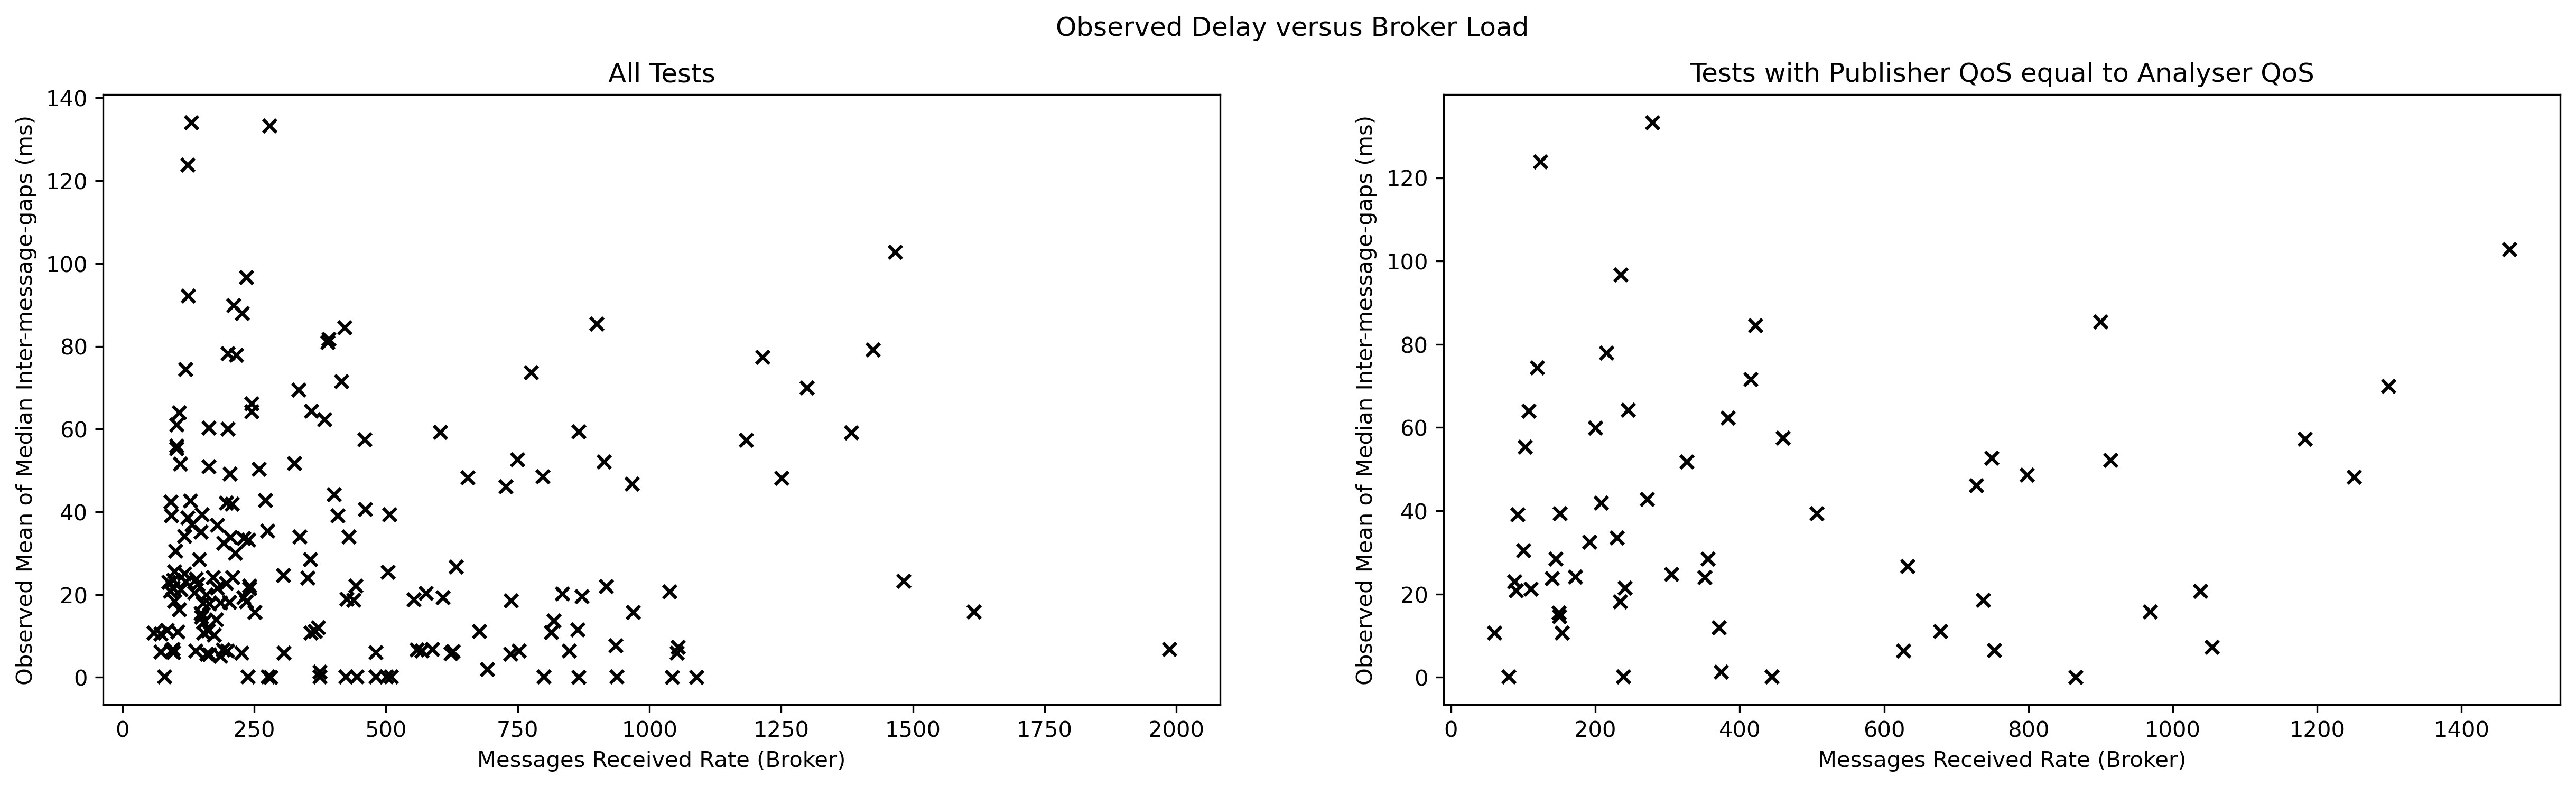

In [58]:
dfs = [df,filtered_df]
fig, axs = plt.subplots(1,2,figsize=(20,5),dpi=300)

for idx,ax in enumerate(axs):
    median_observed_delay = dfs[idx]['median_inter_message_gap']
    broker_messages_received = np.array(dfs[idx]['$SYS/broker/load/messages/received/1min'])/60

    ax.scatter(broker_messages_received, median_observed_delay, color='black', marker='x')
    ax.set_xlabel('Messages Received Rate (Broker)')
    ax.set_ylabel('Observed Mean of Median Inter-message-gaps (ms)')
    ax.set_title(labels[idx])
plt.suptitle('Observed Delay versus Broker Load')
plt.show()

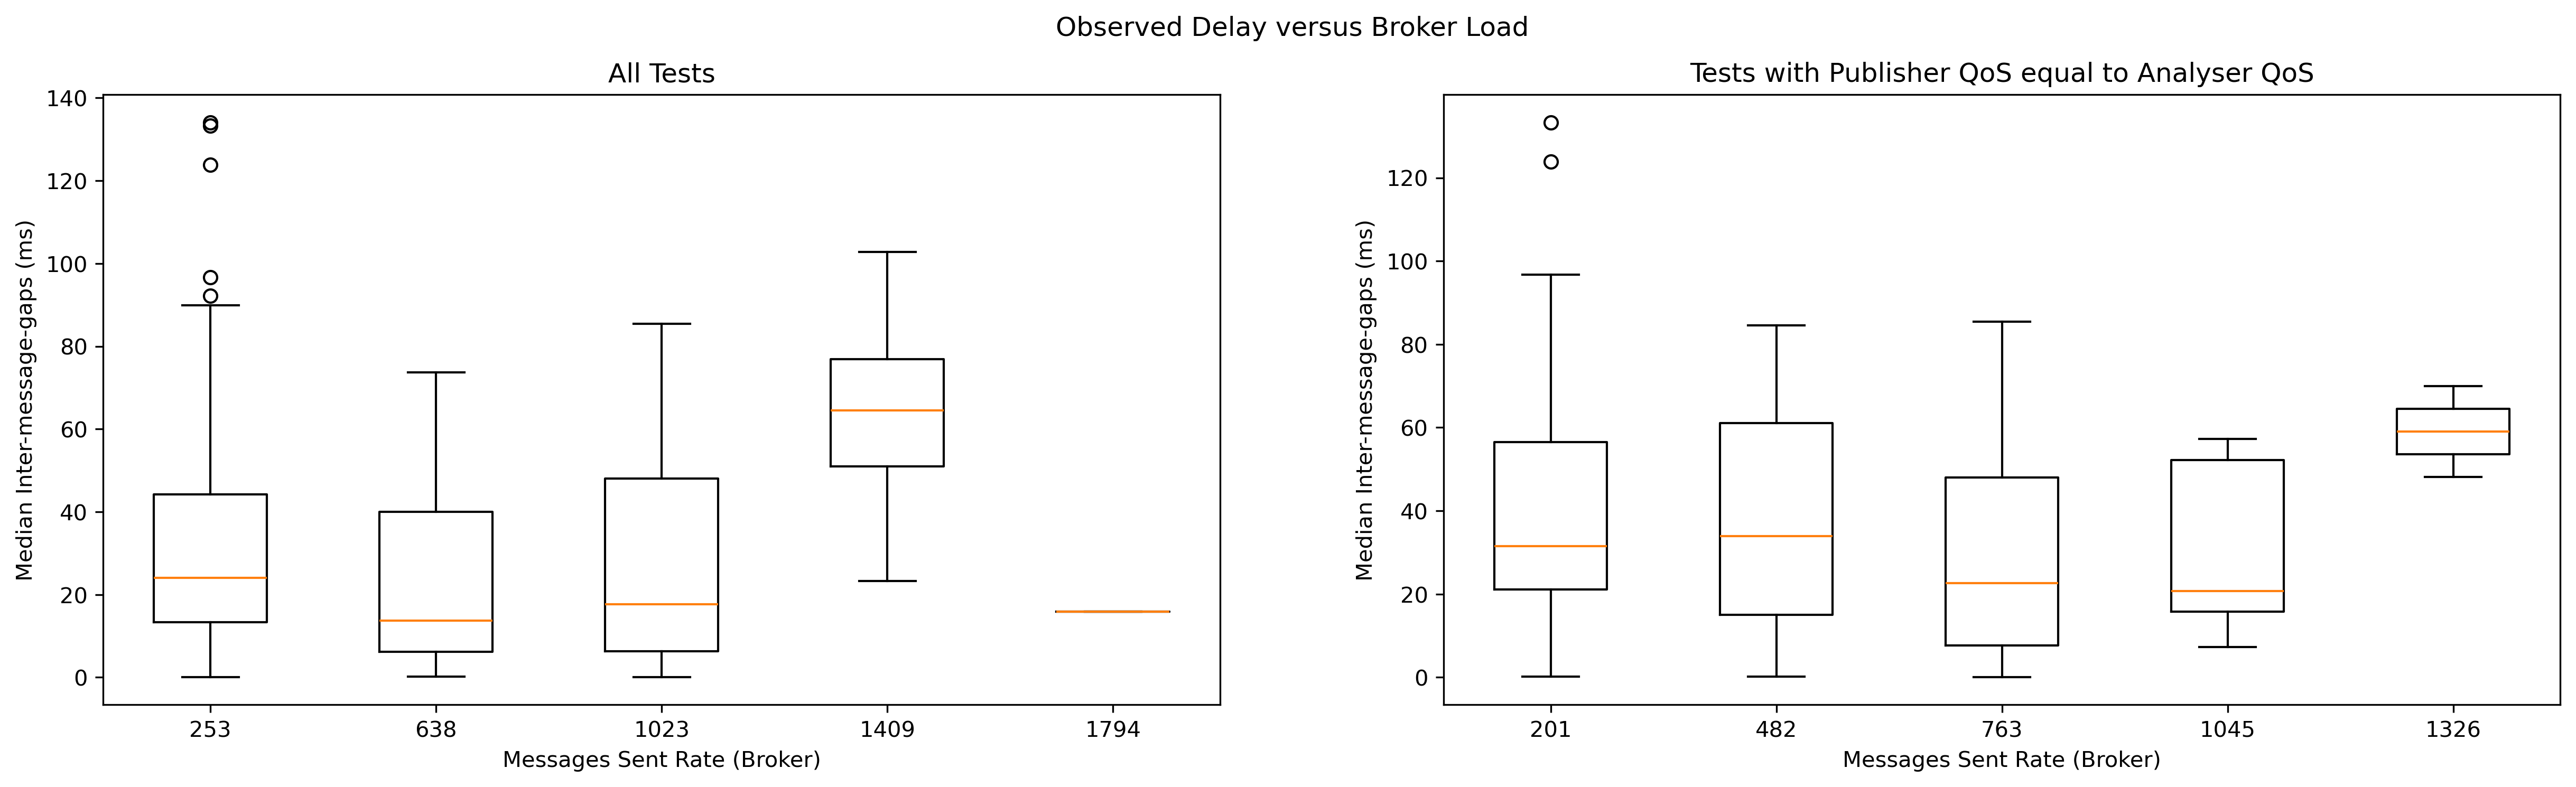

In [59]:
n = 5  # Tuneable number of bins

fig, axs = plt.subplots(1, 2, figsize=(20, 5), dpi=300)

for idx, ax in enumerate(axs):
    median_observed_delay = dfs[idx]['median_inter_message_gap']
    broker_messages_dropped = np.array(dfs[idx]['$SYS/broker/load/messages/received/1min']) / 60

    # Creating bins
    bins = np.linspace(broker_messages_dropped.min(), broker_messages_dropped.max(), n + 1)
    bin_labels = np.digitize(broker_messages_dropped, bins) - 1

    # Grouping data into bins
    binned_data = [median_observed_delay[bin_labels == i] for i in range(n)]

    # Plotting boxplot
    ax.boxplot(binned_data, positions=(bins[:-1] + bins[1:]) / 2, widths=np.diff(bins) / 2)
    ax.set_xticks([bins[i]+(bins[i+1]-bins[i])/2 for i in range(n)])
    ax.set_xticklabels([f"{round(bins[i]+(bins[i+1]-bins[i])/2)}" for i in range(n)])
    # ax.set_xticklabels([f'{bins[i]:.1f}' for i in range(n)], rotation=45)

    ax.set_xlabel('Messages Sent Rate (Broker)')
    ax.set_ylabel('Median Inter-message-gaps (ms)')
    ax.set_title(labels[idx])

plt.suptitle('Observed Delay versus Broker Load')
plt.show()

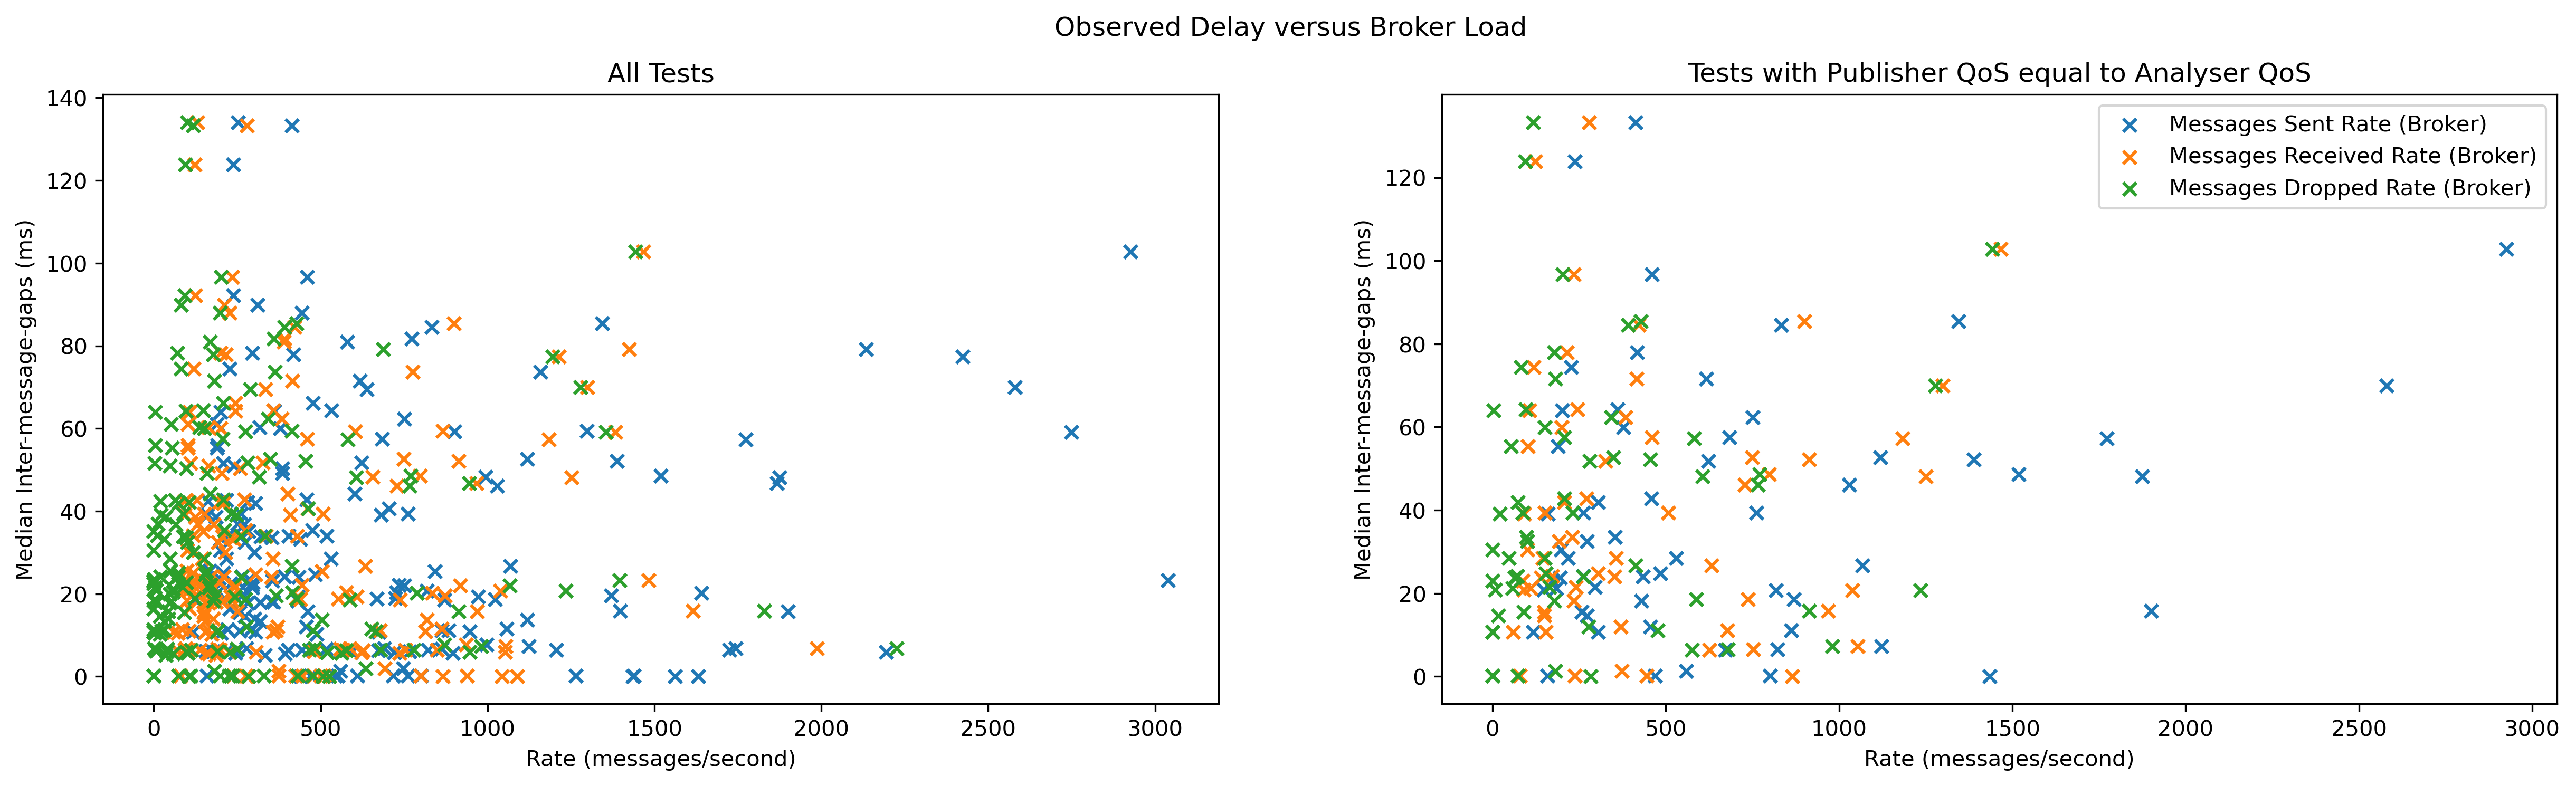

In [67]:
dfs = [df,filtered_df]
fig, axs = plt.subplots(1,2,figsize=(20,5),dpi=300)

for idx,ax in enumerate(axs):
    median_observed_delay = dfs[idx]['median_inter_message_gap']
    broker_messages_dropped = np.array(dfs[idx]['$SYS/broker/load/publish/dropped/1min'])/60
    broker_messages_received = np.array(dfs[idx]['$SYS/broker/load/messages/received/1min'])/60
    broker_messages_sent = np.array(dfs[idx]['$SYS/broker/load/messages/sent/1min'])/60

    ax.scatter(broker_messages_sent, median_observed_delay, color='C0', marker='x', label='Messages Sent Rate (Broker)')
    ax.scatter(broker_messages_received, median_observed_delay, color='C1', marker='x', label='Messages Received Rate (Broker)')
    ax.scatter(broker_messages_dropped, median_observed_delay, color='C2', marker='x', label='Messages Dropped Rate (Broker)')
    ax.set_xlabel('Rate (messages/second)')
    ax.set_ylabel('Median Inter-message-gaps (ms)')
    ax.set_title(labels[idx])
plt.suptitle('Observed Delay versus Broker Load')
plt.legend()
plt.show()

Interestingly, there's no immediately apparent correlation between broker stress and observed delay.

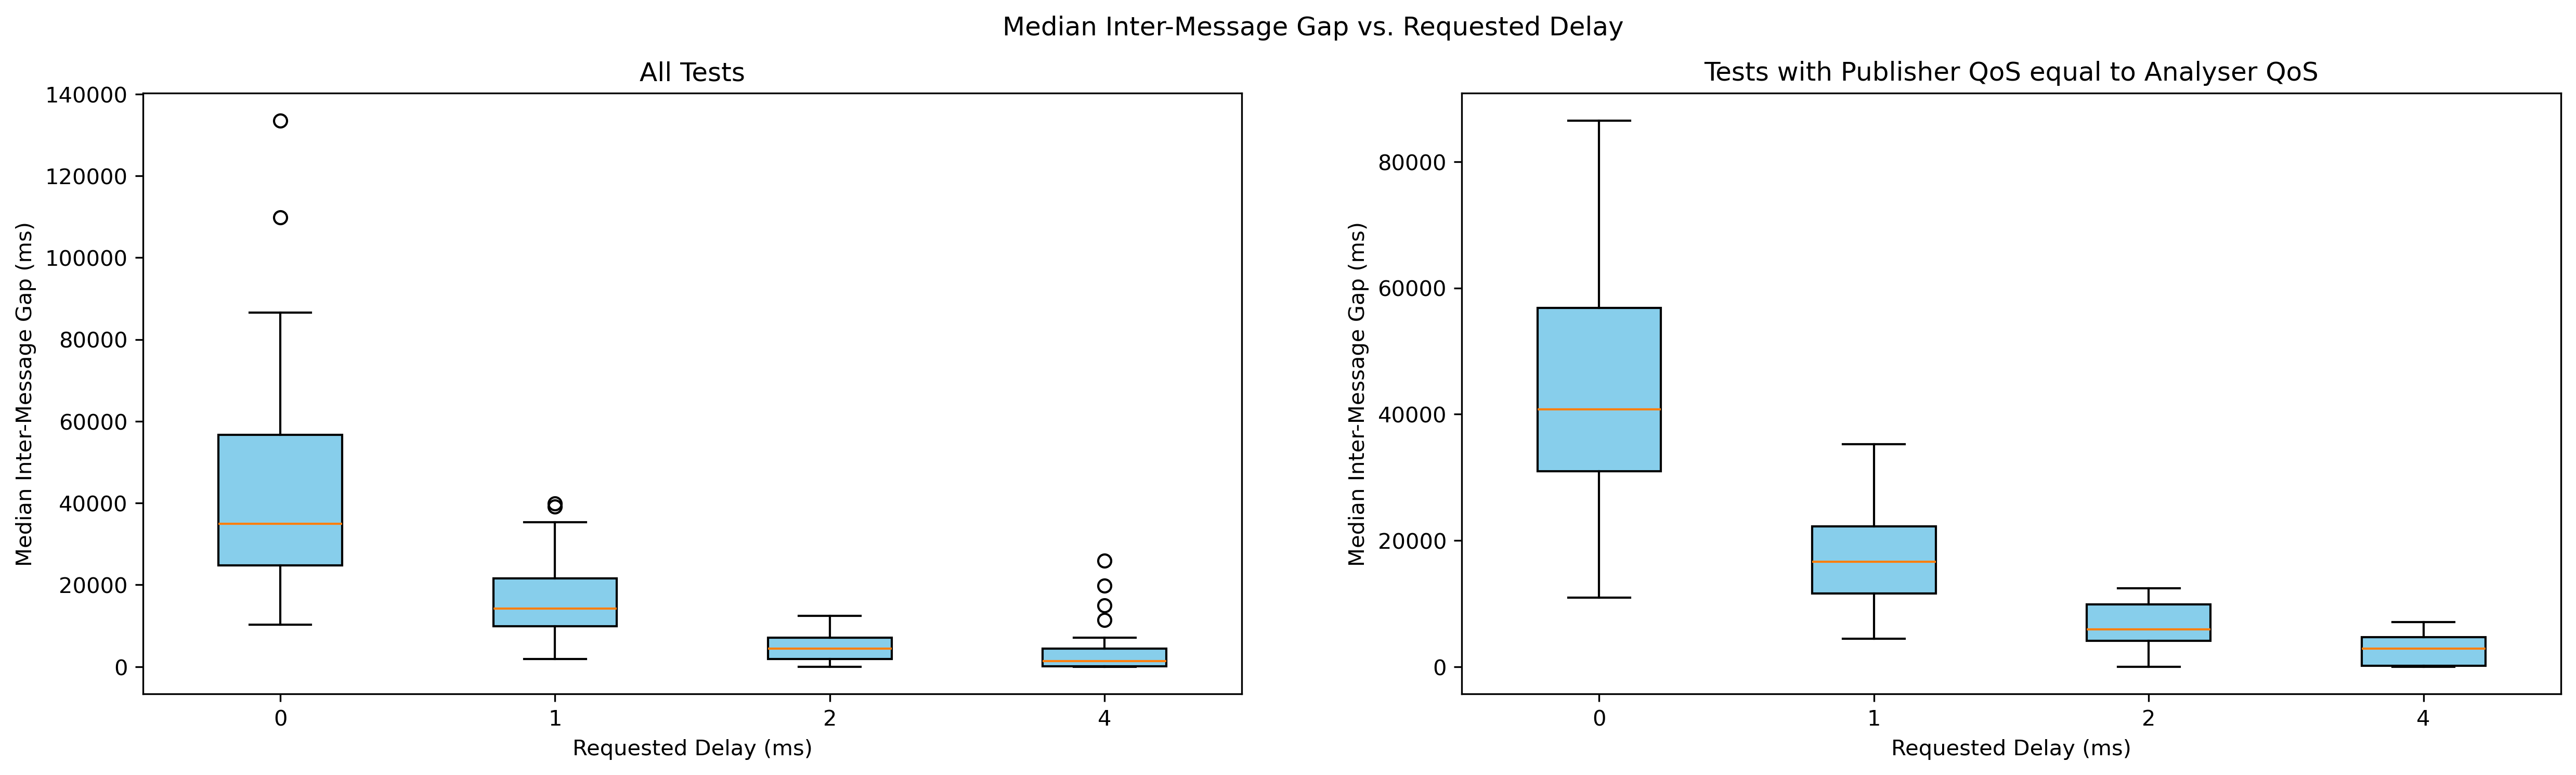

In [60]:
fig, axs = plt.subplots(1, 2, figsize=(20, 5), dpi=300)
dfs = [df, filtered_df]

for idx, ax in enumerate(axs):
    # Group data by 'qos' and collect the 'median_inter_message_gap' values
    grouped_data = [dfs[idx].loc[dfs[idx]['delay'] == delay, '$SYS/broker/load/publish/dropped/1min'] for delay in [0, 1, 2, 4]]
    
    # Create a box plot
    ax.boxplot(grouped_data, labels=[0, 1, 2, 4], patch_artist=True, boxprops=dict(facecolor="skyblue"))
    ax.set_ylabel('Median Inter-Message Gap (ms)')
    ax.set_xlabel('Requested Delay (ms)')
    ax.set_title(labels[idx])
    ax.set_xticks([1, 2, 3, 4])  # Set the x-ticks to correspond to the QoS labels

plt.suptitle('Median Inter-Message Gap vs. Requested Delay')
plt.show()

Clearly, increasing Publisher delay dramatically reduces messages dropped by broker. Does this mean anything though? If twice as little messages are dropped for requested delay 2ms compared to requested delay 1ms, this isn't any improvement in performance - it just stems from the fact we're sending the Broker less messages. 

## Contourplots/Colourmaps

* Instancecount versus QOS with colour representing send rate
* Instancecount versus QOS with colour representing dropped rate 


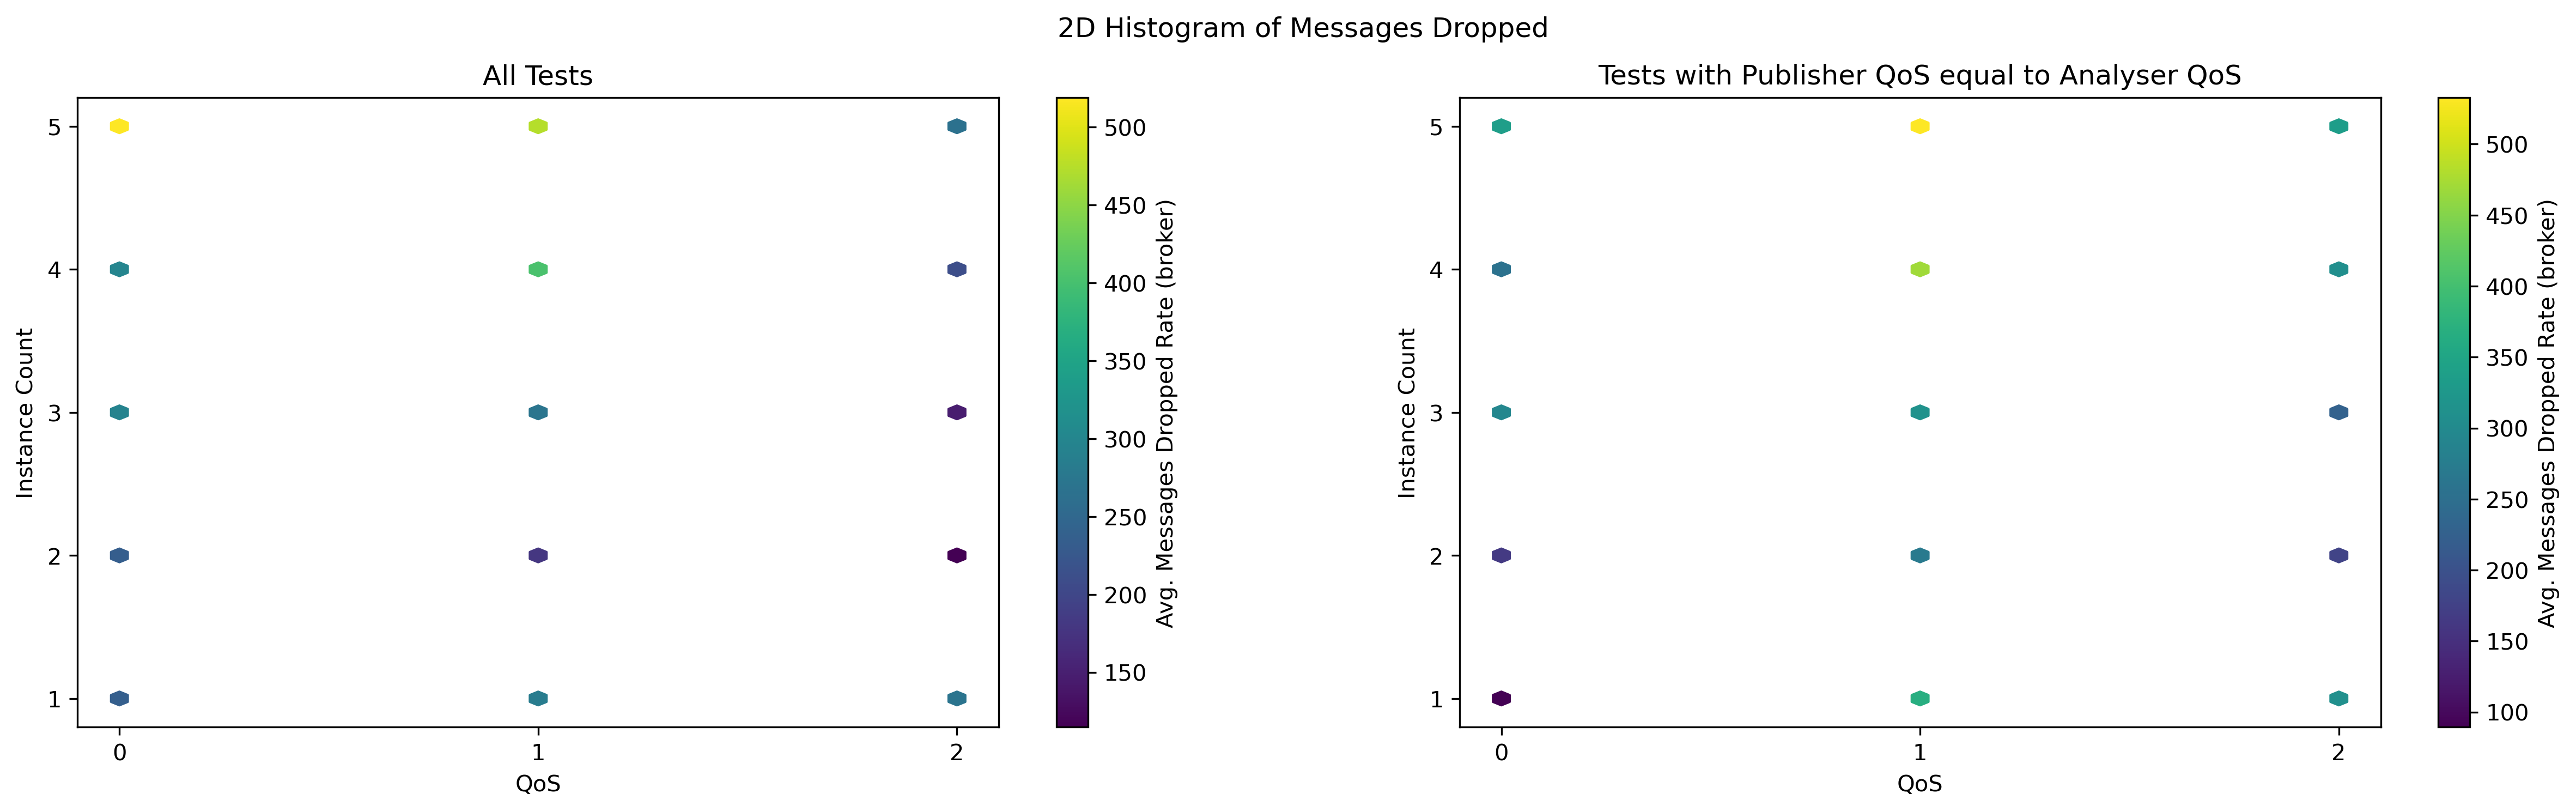

In [61]:
dfs = [df, filtered_df]
fig, axs = plt.subplots(1, 2, figsize=(20, 5), dpi=300)

for idx, ax in enumerate(axs):
    x = dfs[idx]['qos']
    y = dfs[idx]['instancecount']
    z = dfs[idx]['$SYS/broker/load/publish/dropped/1min']
    hb = ax.hexbin(x, y, C=z/60, gridsize=50, cmap='viridis', reduce_C_function=np.mean)
    ax.set_title(labels[idx])
    ax.set_xlabel('QoS')
    ax.set_ylabel('Instance Count')
    ax.set_xticks([0,1,2])
    ax.set_yticks([1,2,3,4,5])
    fig.colorbar(hb, ax=ax, label='Avg. Messages Dropped Rate (broker)')

plt.suptitle('2D Histogram of Messages Dropped')
plt.show()


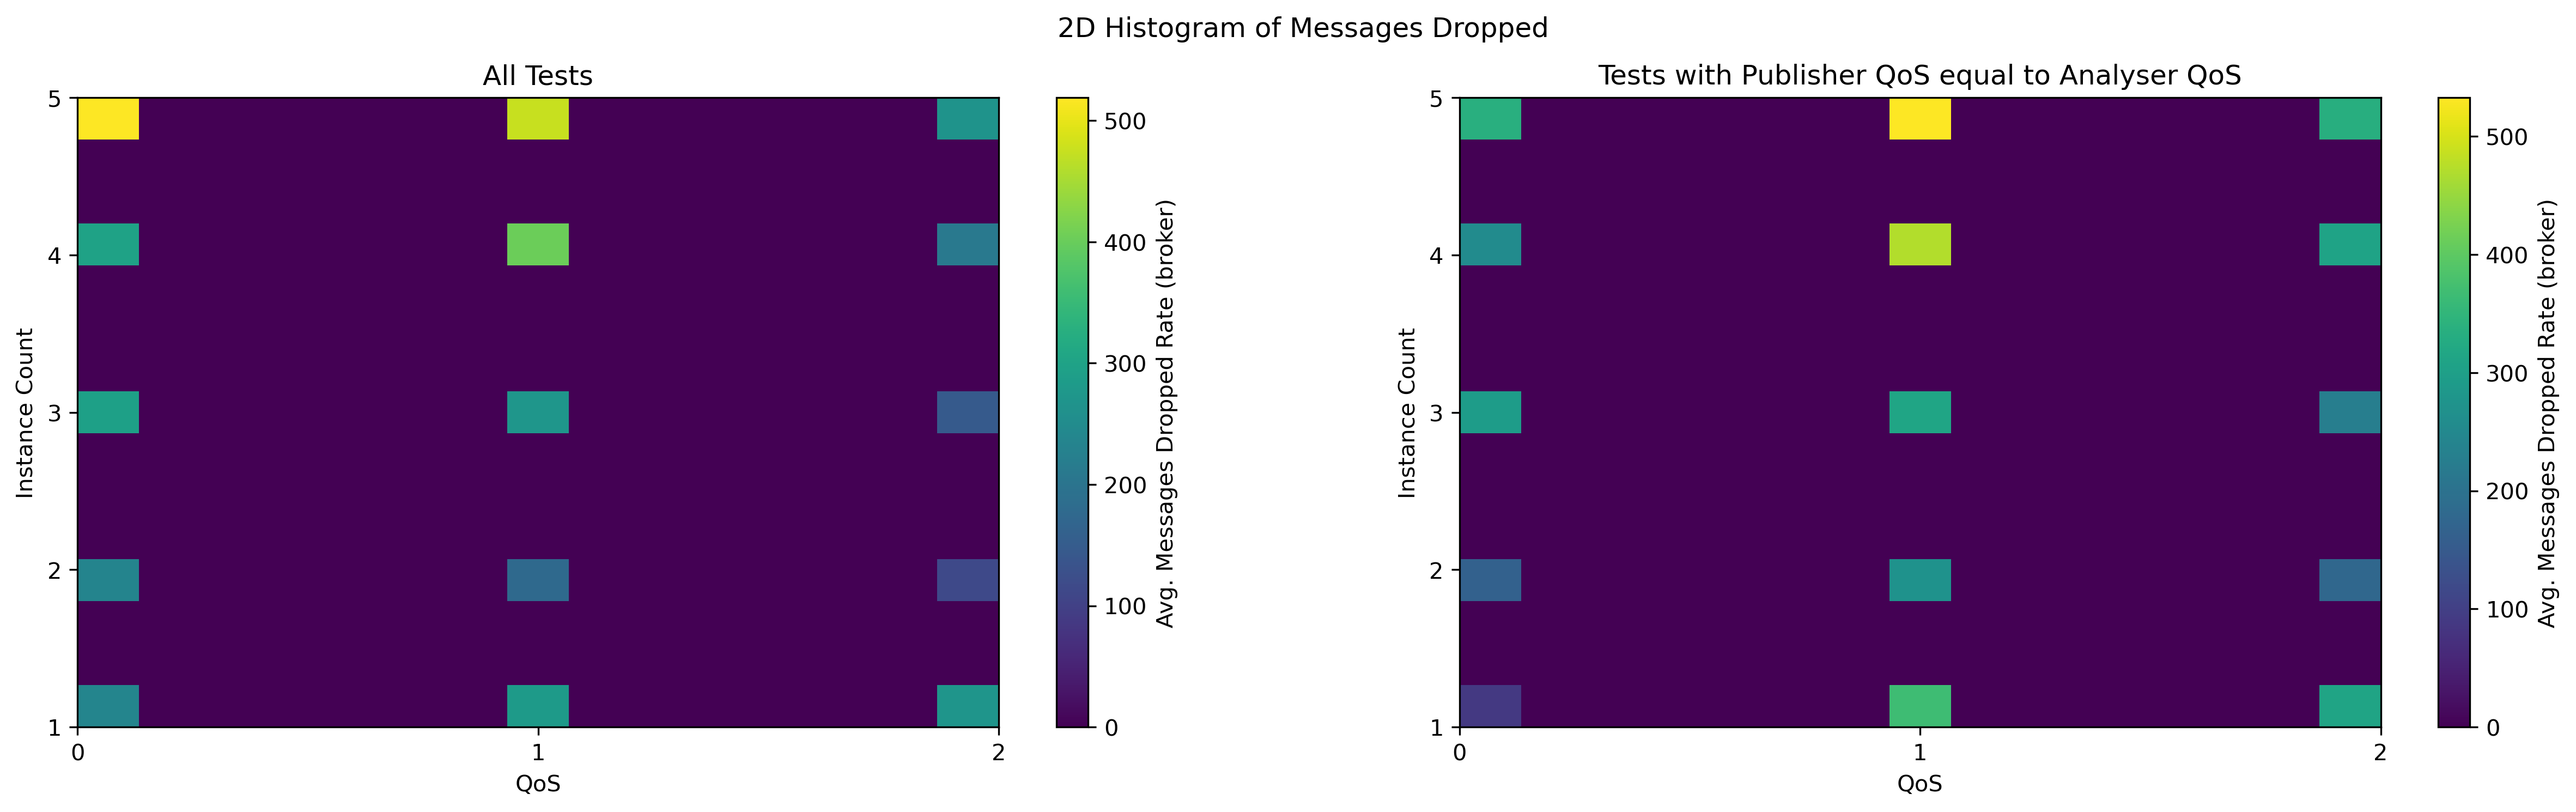

In [62]:
dfs = [df, filtered_df]
fig, axs = plt.subplots(1, 2, figsize=(20, 5), dpi=300)

for idx, ax in enumerate(axs):
    x = dfs[idx]['qos']
    y = dfs[idx]['instancecount']
    z = dfs[idx]['$SYS/broker/load/publish/dropped/1min'] / 60

    # Compute the 2D histogram
    counts, xedges, yedges = np.histogram2d(x, y, bins=15)
    sums, _, _ = np.histogram2d(x, y, bins=15, weights=z)
    means = np.divide(sums, counts, where=counts!=0)  # Compute mean values

    # Plot the 2D histogram as an image
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    im = ax.imshow(means.T, extent=extent, origin='lower', cmap='viridis', aspect='auto')
    ax.set_title(labels[idx])
    ax.set_xlabel('QoS')
    ax.set_ylabel('Instance Count')
    ax.set_yticks([1,2,3,4,5])
    ax.set_xticks([0,1,2])
    fig.colorbar(im, ax=ax, label='Avg. Messages Dropped Rate (broker)')

plt.suptitle('2D Histogram of Messages Dropped')
plt.show()


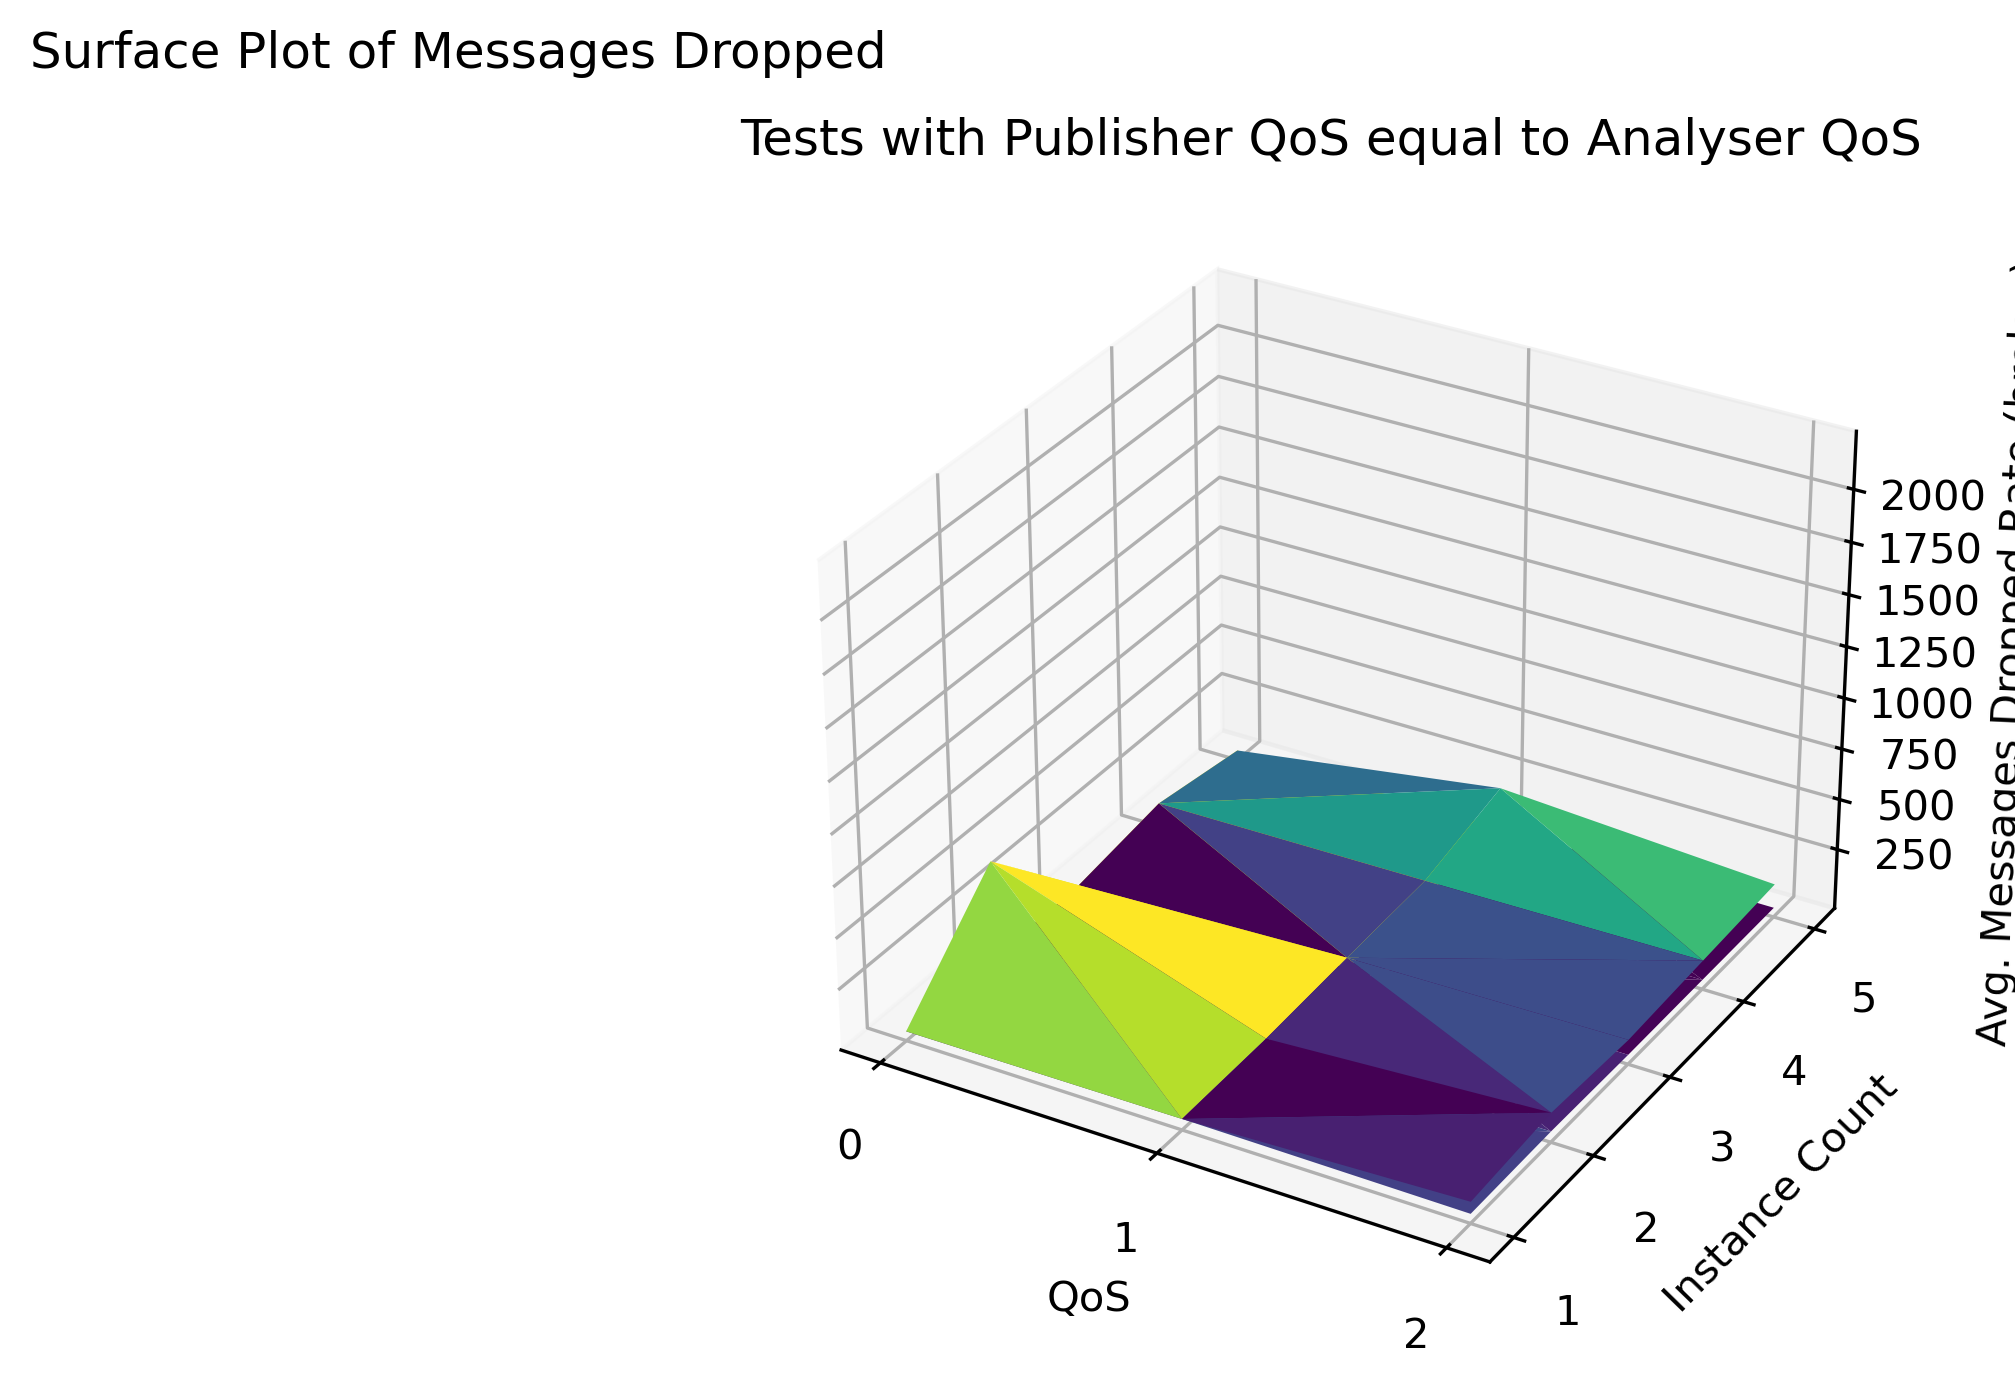

In [63]:
dfs = [df, filtered_df]
fig = plt.figure(figsize=(13, 5), dpi=300)
ax = fig.add_subplot(1, 2, idx+1, projection='3d')

for idx, _ in enumerate(dfs):
    x = dfs[idx]['qos']
    y = dfs[idx]['instancecount']
    z = dfs[idx]['$SYS/broker/load/publish/dropped/1min'] / 60

    ax.plot_trisurf(x, y, z, cmap='viridis', edgecolor='none')
    ax.set_title(labels[idx])
    ax.set_xlabel('QoS')
    ax.set_xticks([0,1,2])
    ax.set_yticks([1,2,3,4,5])
    ax.set_ylabel('Instance Count')
    ax.set_zlabel('Avg. Messages Dropped Rate (broker)')

plt.suptitle('Surface Plot of Messages Dropped')
plt.show()


## What else?

* Discuss interesting delivery patterns I collected in figures throughout the test process

In [64]:
from typing import *
from ast import literal_eval

class PublisherData:

    def __init__(self, data: List):
        self.count, self.time = zip(*data)
        self.count = np.array(self.count).astype('int')
        self.time = np.array(self.time).astype('float')

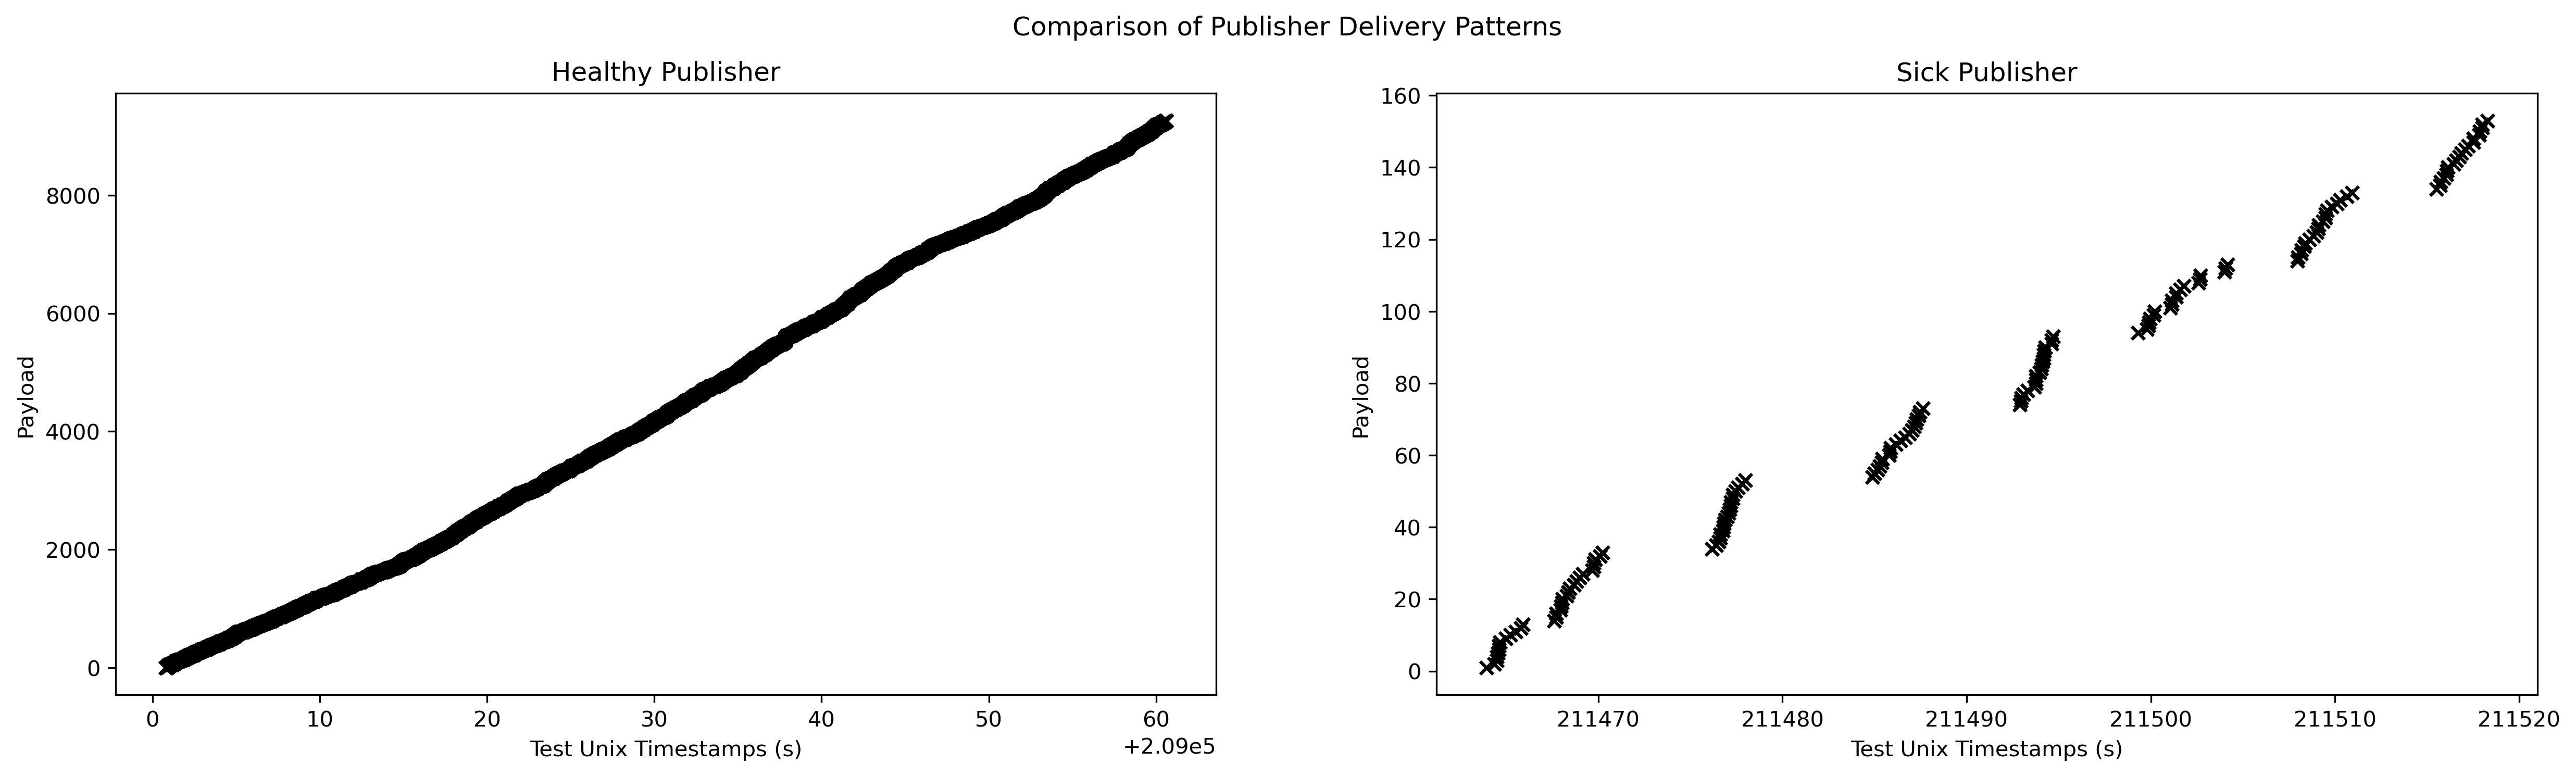

In [80]:
healthy_df = pd.read_excel('/Users/timothyalder/Documents/ANU/ENGN3539/Assignment-Three/test-1/data/0_0_1_0.xlsx')
healthy = healthy_df["counter/pub-1/0/0"].dropna()
healthy = PublisherData(healthy.apply(literal_eval))
sick_df = pd.read_excel('/Users/timothyalder/Documents/ANU/ENGN3539/Assignment-Three/test-1/data/1_1_5_4.xlsx')
sick = sick_df["counter/pub-1/1/4"].dropna()
sick = PublisherData(sick.apply(literal_eval))
pubs = [healthy,sick]
labels = ['Healthy Publisher','Sick Publisher']

fig,axs = plt.subplots(1,2,figsize=(20,5),dpi=300)
for idx,ax in enumerate(axs):
    ax.scatter(pubs[idx].time,pubs[idx].count,marker='x',color='black')
    ax.set_title(labels[idx])
    ax.set_ylabel('Payload')
    ax.set_xlabel('Test Unix Timestamps (s)')
plt.suptitle('Comparison of Publisher Delivery Patterns')
plt.show()

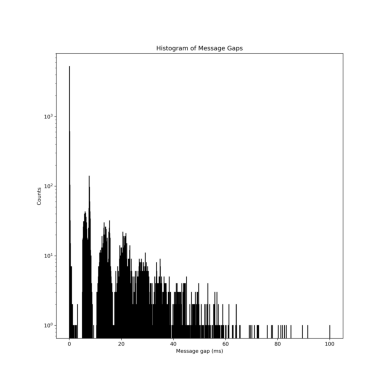

In [81]:
healthy_gaps = plt.imread('/Users/timothyalder/Documents/ANU/ENGN3539/Assignment-Three/test-1/figures/pub-1_0_0_1_0_gaps_distribution.png')
plt.figure()
plt.axis('off')
plt.imshow(healthy_gaps)

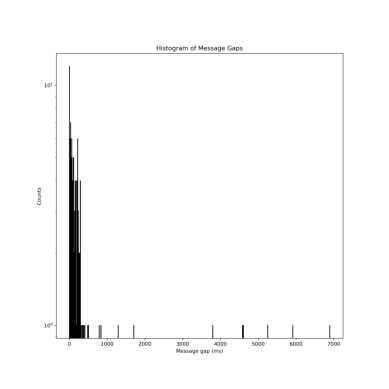

In [78]:
healthy_gaps = plt.imread('/Users/timothyalder/Documents/ANU/ENGN3539/Assignment-Three/test-1/figures/pub-1_1_1_5_4_gaps_distribution.png')
plt.figure()
plt.axis('off')
plt.imshow(healthy_gaps)

In [65]:
test = pd.read_excel('/Users/timothyalder/Documents/ANU/ENGN3539/Assignment-Three/test-1/data/1_1_5_4.xlsx')
pubs = [test[f"counter/pub-{i}/1/4"].dropna() for i in range(1,6,1)]
pubs = [PublisherData(pub.apply(literal_eval)) for pub in pubs]

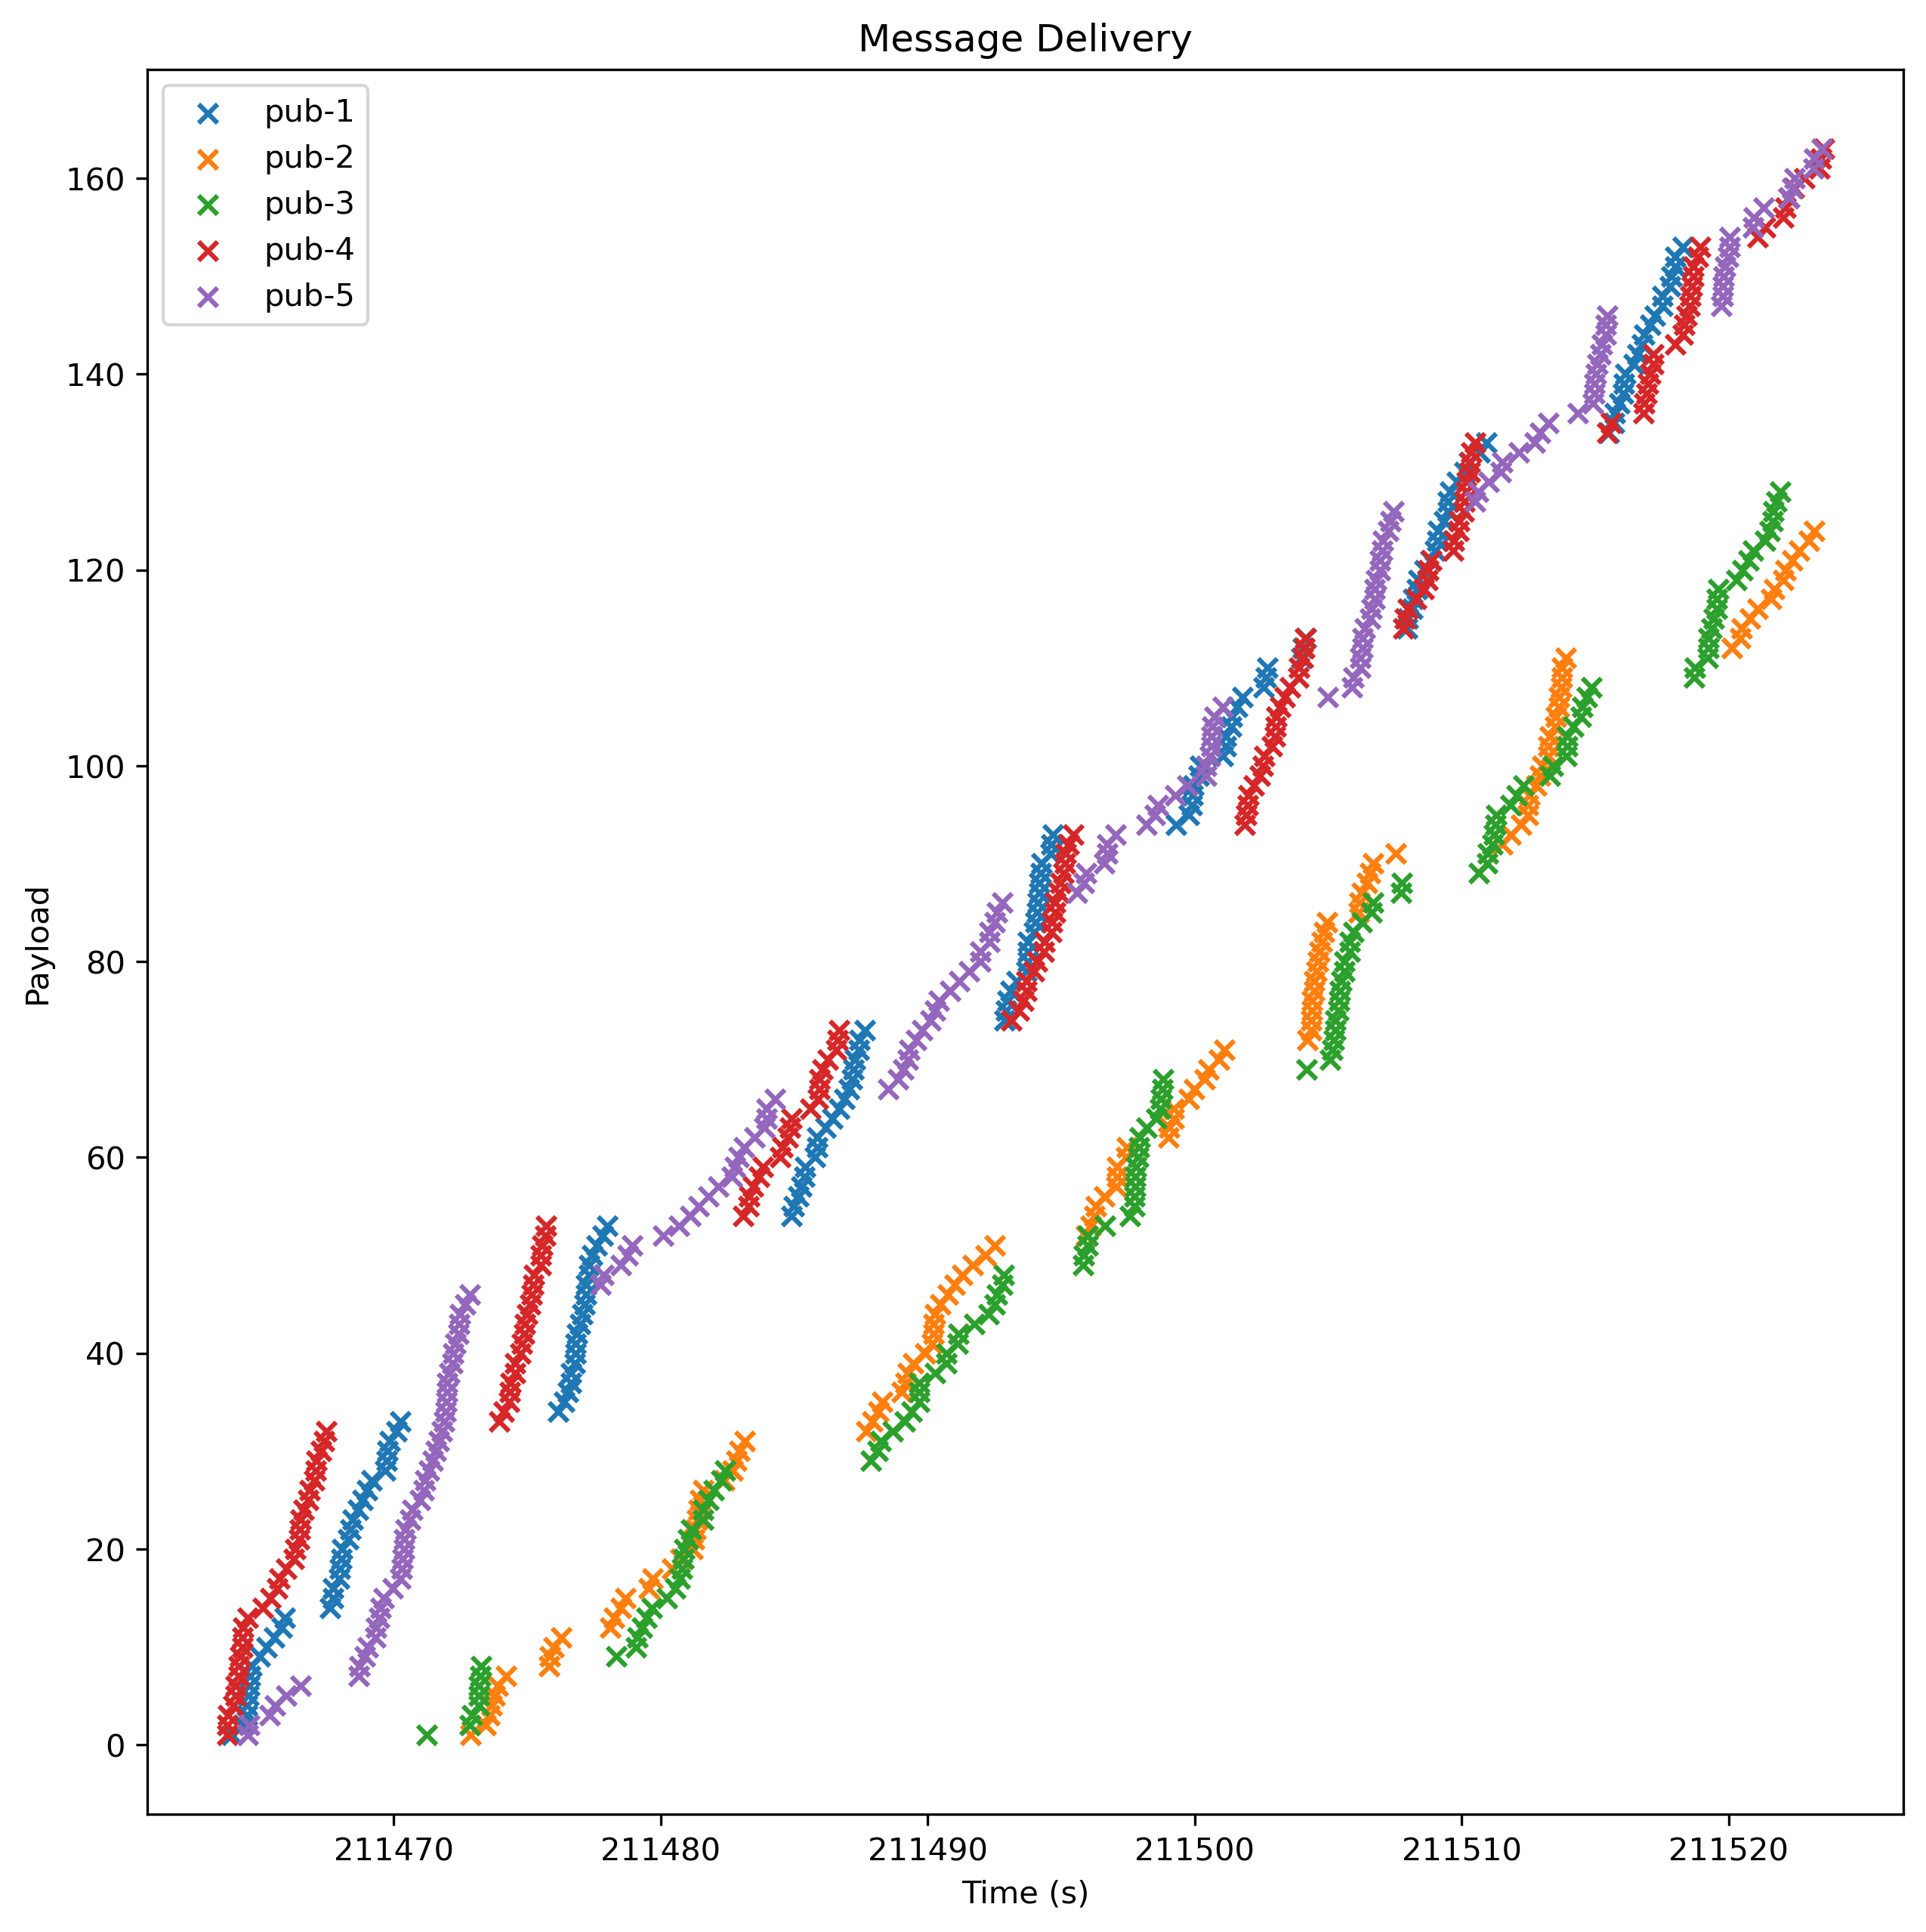

In [66]:
plt.figure(figsize=(10,10),dpi=300)

for idx,pub in enumerate(pubs):
    plt.scatter(pub.time,pub.count,marker='x',label=f'pub-{idx+1}')

plt.title('Message Delivery')
plt.xlabel('Time (s)')
plt.ylabel('Payload')
plt.legend()
plt.show()